In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [10]:
data_path = Path("/Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset")

parquet_files = {
    'papers': data_path / 'papers.parquet',
    'mentions': data_path / 'mentions.pdf.parquet',
    'purpose_assessments': data_path / 'purpose_assessments.pdf.parquet'
}

print("Checking for parquet files:")
for name, file_path in parquet_files.items():
    exists = file_path.exists()
    print(f"{name}: {file_path} - {'✓' if exists else '✗'}")

if all(f.exists() for f in parquet_files.values()):
    print("\nAll files found! Ready to load data.")
else:
    print("\nSome files are missing. Please check the data directory.")


Checking for parquet files:
papers: /Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset/papers.parquet - ✓
mentions: /Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset/mentions.pdf.parquet - ✓
purpose_assessments: /Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset/purpose_assessments.pdf.parquet - ✓

All files found! Ready to load data.


In [11]:
print("Loading parquet files (full dataset — this may take a minute)...")

papers_df = pd.read_parquet(parquet_files['papers'], engine="pyarrow")
print(f"Papers dataset: {papers_df.shape[0]:,} rows, {papers_df.shape[1]} columns")

mentions_df = pd.read_parquet(parquet_files['mentions'], engine="pyarrow")
print(f"Mentions dataset: {mentions_df.shape[0]:,} rows, {mentions_df.shape[1]} columns")

purpose_df = pd.read_parquet(parquet_files['purpose_assessments'], engine="pyarrow")
print(f"Purpose assessments dataset: {purpose_df.shape[0]:,} rows, {purpose_df.shape[1]} columns")

print("\nData loaded successfully!")
 

Loading parquet files (full dataset — this may take a minute)...
Papers dataset: 320,866 rows, 13 columns
Mentions dataset: 2,777,758 rows, 15 columns
Purpose assessments dataset: 16,666,548 rows, 7 columns

Data loaded successfully!


# Look at the initial heads for the dataframes


In [12]:
papers_df.head()

,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
0,84,00003a57-7df8-4951-bc85-8b49e7b8d8ad,Scalability and feasibility of photoelectroche...,2015,2015-01-01,Energy &amp; Environmental Science,Royal Society of Chemistry (RSC),10.1039/c5ee02188j,,,journal-article,,True
1,165,00007678-4c96-4f8f-af0b-a9057e609234,Early prediction of paratuberculosis health st...,2022,2022-08-12,,Research Square Platform LLC,10.21203/rs.3.rs-1929091/v1,,,posted-content,,True
2,196,00008d79-abca-4c1b-a995-d7452bd804de,A Comparison of DNA Pools Constructed Followin...,2005,2005-08-01,Twin Research and Human Genetics,Cambridge University Press (CUP),10.1375/1832427054936718,,,journal-article,,True
3,294,0000d6e5-ae77-4518-9a28-0560b77401aa,DicomBrowser: Software for Viewing and Modifyi...,2012,2012-02-15,Journal of Digital Imaging,Springer Science and Business Media LLC,10.1007/s10278-012-9462-x,PMC3447088,22349992,journal-article,,True
4,313,0000e448-bd17-4865-913b-9ee4e483edd4,Validation of the Arabic version of the SCOFF ...,2015,2015-05-01,Eastern Mediterranean Health Journal,World Health Organization Regional Office for ...,10.26719/2015.21.5.326,,26343121,journal-article,,True


In [6]:
mentions_df.head()

,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
0,84.pdf.00000,84,pdf,0,ImageJ,ImageJ,,,,,,,,,The size of the nanoparticles on the pictures ...
1,84.pdf.00001,84,pdf,1,EC Lab,EC Lab,,,,,,,,,"For the photoelectrochemical measurements, a B..."
2,165.pdf.00000,165,pdf,0,MagMET,MagMET,,,,,,,,,MagMET allows for qualitative and quantitative...
3,165.pdf.00001,165,pdf,1,AVAILABILITY STATEMENT,AVAILABILITY STATEMENT,,,,,,,,,SOFTWARE OR DATABASE AVAILABILITY STATEMENT T...
4,165.pdf.00002,165,pdf,2,Metaboanalyst,Metaboanalyst,,,,,,,www.metaboanalyst.ca,www.metaboanalyst.ca,Since the pathway analysis on the Metaboanalys...


In [7]:
purpose_df.head(40)

,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
0,84.pdf.00000,84,pdf,0,document,created,6.556511e-06
1,84.pdf.00000,84,pdf,0,document,shared,1.192093e-07
2,84.pdf.00000,84,pdf,0,document,used,9.999969e-01
3,84.pdf.00000,84,pdf,0,local,created,6.556511e-06
4,84.pdf.00000,84,pdf,0,local,shared,1.192093e-07
5,84.pdf.00000,84,pdf,0,local,used,9.999969e-01
6,84.pdf.00001,84,pdf,1,document,created,4.541874e-05
7,84.pdf.00001,84,pdf,1,document,shared,1.192093e-07
8,84.pdf.00001,84,pdf,1,document,used,9.999943e-01
9,84.pdf.00001,84,pdf,1,local,created,4.541874e-05


## Section 2: Dataset Overview

Schema, data types, descriptive statistics, and missing-value audit for each table.

In [13]:
print("=" * 60)
print("PAPERS TABLE")
print("=" * 60)
papers_df.info()
print()
papers_df.describe(include="all")

PAPERS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320866 entries, 0 to 320865
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   paper_id           320866 non-null  uint32
 1   softcite_id        320866 non-null  object
 2   title              320866 non-null  object
 3   published_year     320866 non-null  uint16
 4   published_date     320866 non-null  object
 5   publication_venue  320866 non-null  object
 6   publisher_name     320866 non-null  object
 7   doi                320866 non-null  object
 8   pmcid              320866 non-null  object
 9   pmid               320866 non-null  object
 10  genre              320866 non-null  object
 11  license_type       320866 non-null  object
 12  has_mentions       320866 non-null  bool  
dtypes: bool(1), object(10), uint16(1), uint32(1)
memory usage: 26.6+ MB



,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
count,3.208660e+05,320866,320866,320866.000000,320866,320866,320866,320866,320866,320866,320866,320866,320866
unique,NaN,320866,318558,NaN,8784,45527,9586,320866,113126,144087,29,9,1
top,NaN,00003a57-7df8-4951-bc85-8b49e7b8d8ad,,NaN,1970-01-01,,Springer Science and Business Media LLC,10.1039/c5ee02188j,,,journal-article,,True
freq,NaN,1,1118,NaN,6682,34926,36781,1,207726,176762,261299,240375,320866
mean,1.187695e+07,NaN,NaN,1975.052467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6.859927e+06,NaN,NaN,285.311313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.400000e+01,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.929754e+06,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.189220e+07,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.782157e+07,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
papers_df[papers_df['published_year'] > 2025][['paper_id', 'title', 'doi', 'published_year', 'published_date']]

,paper_id,title,doi,published_year,published_date
219074,16227920,The Current Situation of Primary School Teache...,10.20431/2349-0381.0303008,2106,2106-01-01


In [15]:
print("=" * 60)
print("MENTIONS TABLE")
print("=" * 60)
mentions_df.info()
print()
mentions_df.describe(include="all")

MENTIONS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2777758 entries, 0 to 2777757
Data columns (total 15 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   software_mention_id   object
 1   paper_id              uint32
 2   source_file_type      object
 3   mention_index         uint16
 4   software_raw          object
 5   software_normalized   object
 6   version_raw           object
 7   version_normalized    object
 8   publisher_raw         object
 9   publisher_normalized  object
 10  language_raw          object
 11  language_normalized   object
 12  url_raw               object
 13  url_normalized        object
 14  context_full_text     object
dtypes: object(13), uint16(1), uint32(1)
memory usage: 291.4+ MB



,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
count,2777758,2.777758e+06,2777758,2.777758e+06,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758
unique,2777758,NaN,1,NaN,234137,221434,19461,18744,28538,25062,184,179,21782,21484,2123899
top,84.pdf.00000,NaN,pdf,NaN,LaTeX,LaTeX,,,,,,,,,An error in the conversion from LaTeX to XML h...
freq,1,NaN,2777758,NaN,117252,117252,2220254,2220254,2457319,2457319,2713359,2713359,2679639,2679639,35023
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,6.804224e+06,NaN,1.990968e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
print("=" * 60)
print("PURPOSE ASSESSMENTS TABLE")
print("=" * 60)
purpose_df.info()
print()
purpose_df.describe(include="all")

PURPOSE ASSESSMENTS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16666548 entries, 0 to 16666547
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   software_mention_id  object 
 1   paper_id             uint32 
 2   source_file_type     object 
 3   mention_index        uint16 
 4   scope                object 
 5   purpose              object 
 6   certainty_score      float64
dtypes: float64(1), object(4), uint16(1), uint32(1)
memory usage: 731.1+ MB



,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
count,16666548,1.666655e+07,16666548,1.666655e+07,16666548,16666548,1.666655e+07
unique,2777758,NaN,1,NaN,2,3,NaN
top,84.pdf.00000,NaN,pdf,NaN,document,created,NaN
freq,6,NaN,16666548,NaN,8333274,5555516,NaN
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,3.281964e-01
std,NaN,6.804223e+06,NaN,1.990968e+03,NaN,NaN,4.530572e-01
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,1.192093e-07
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,1.788139e-06
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,2.143979e-04
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,9.945893e-01


In [20]:
def missing_summary(df, name):
    """Build a summary table of missing values per column."""
    total = len(df)
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    dtypes = df.dtypes
    summary = pd.DataFrame({
        "dtype": dtypes,
        "non_null": total - missing,
        "missing": missing,
        "missing_pct": pct
    })
    summary = summary[summary["missing"] > 0].sort_values("missing_pct", ascending=False)
    if summary.empty:
        print(f"{name}: No missing values!")
    else:
        print(f"\n{name} — columns with missing values ({len(summary)} of {len(df.columns)}):")
        display(summary)
    return summary

_ = missing_summary(papers_df, "Papers")
_ = missing_summary(mentions_df, "Mentions")
_ = missing_summary(purpose_df, "PurposeAssessments")

Papers: No missing values!
Mentions: No missing values!
PurposeAssessments: No missing values!


## Section 3: Papers Table Analysis

Publication trends, genre and license distributions, top venues/publishers, and the proportion of papers with detected software mentions.

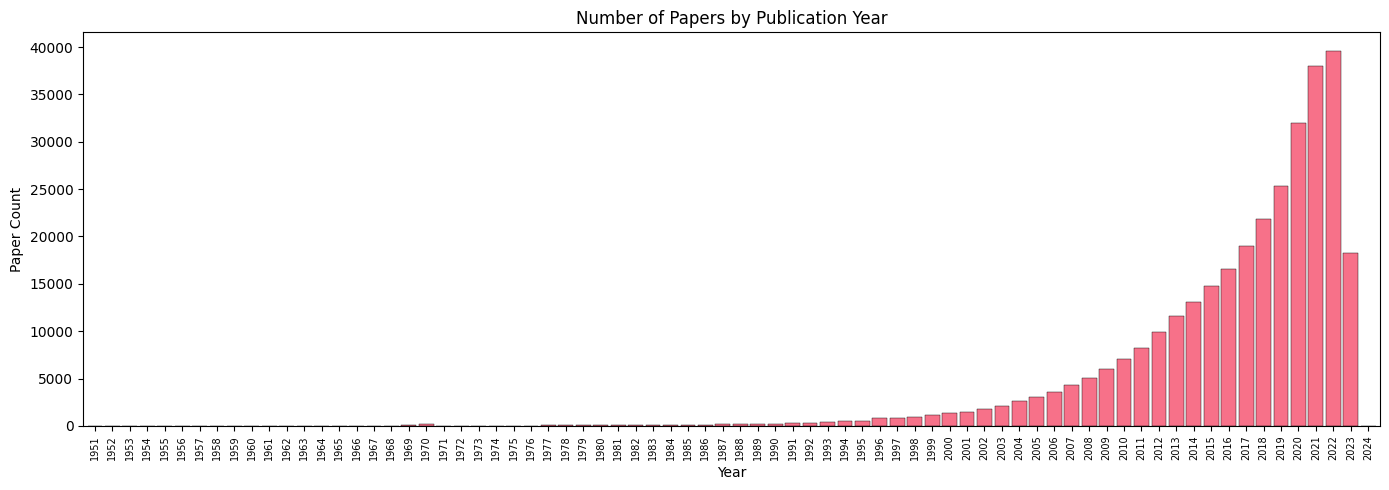

Year range: 1951 - 2024
Median year: 2018
Papers with missing year: 0


In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
year_counts = papers_df['published_year'].dropna().astype(int)
year_counts = year_counts[(year_counts >= 1950) & (year_counts <= 2025)]
year_counts.value_counts().sort_index().plot(kind='bar', ax=ax, width=0.85, edgecolor='black', linewidth=0.3)
ax.set_title("Number of Papers by Publication Year")
ax.set_xlabel("Year")
ax.set_ylabel("Paper Count")
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Year range: {year_counts.min()} - {year_counts.max()}")
print(f"Median year: {int(year_counts.median())}")
print(f"Papers with missing year: {papers_df['published_year'].isna().sum():,}")

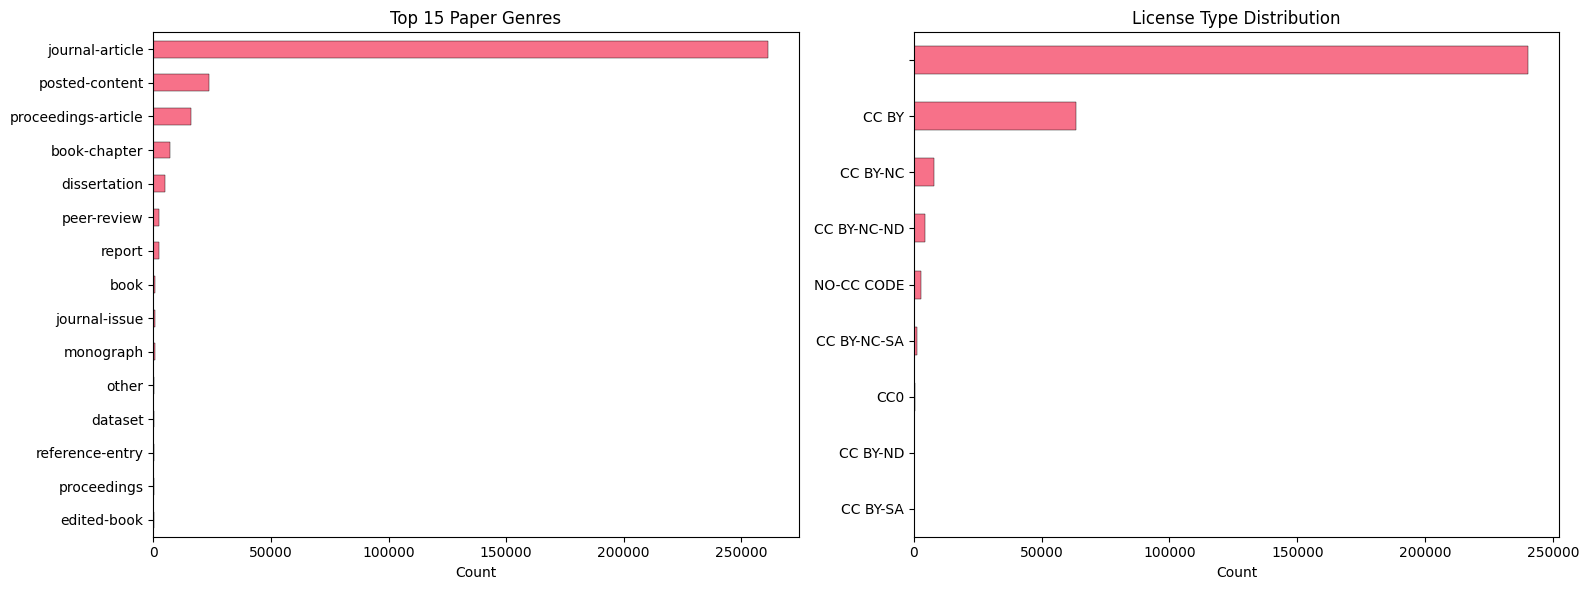

Unique genres: 29
Papers with missing genre: 0

Unique license types: 9
Papers with missing license: 0


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

genre_counts = papers_df['genre'].value_counts().head(15)
genre_counts.plot(kind='barh', ax=axes[0], edgecolor='black', linewidth=0.3)
axes[0].set_title("Top 15 Paper Genres")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

license_counts = papers_df['license_type'].value_counts()
license_counts.plot(kind='barh', ax=axes[1], edgecolor='black', linewidth=0.3)
axes[1].set_title("License Type Distribution")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Unique genres: {papers_df['genre'].nunique()}")
print(f"Papers with missing genre: {papers_df['genre'].isna().sum():,}")
print(f"\nUnique license types: {papers_df['license_type'].nunique()}")
print(f"Papers with missing license: {papers_df['license_type'].isna().sum():,}")

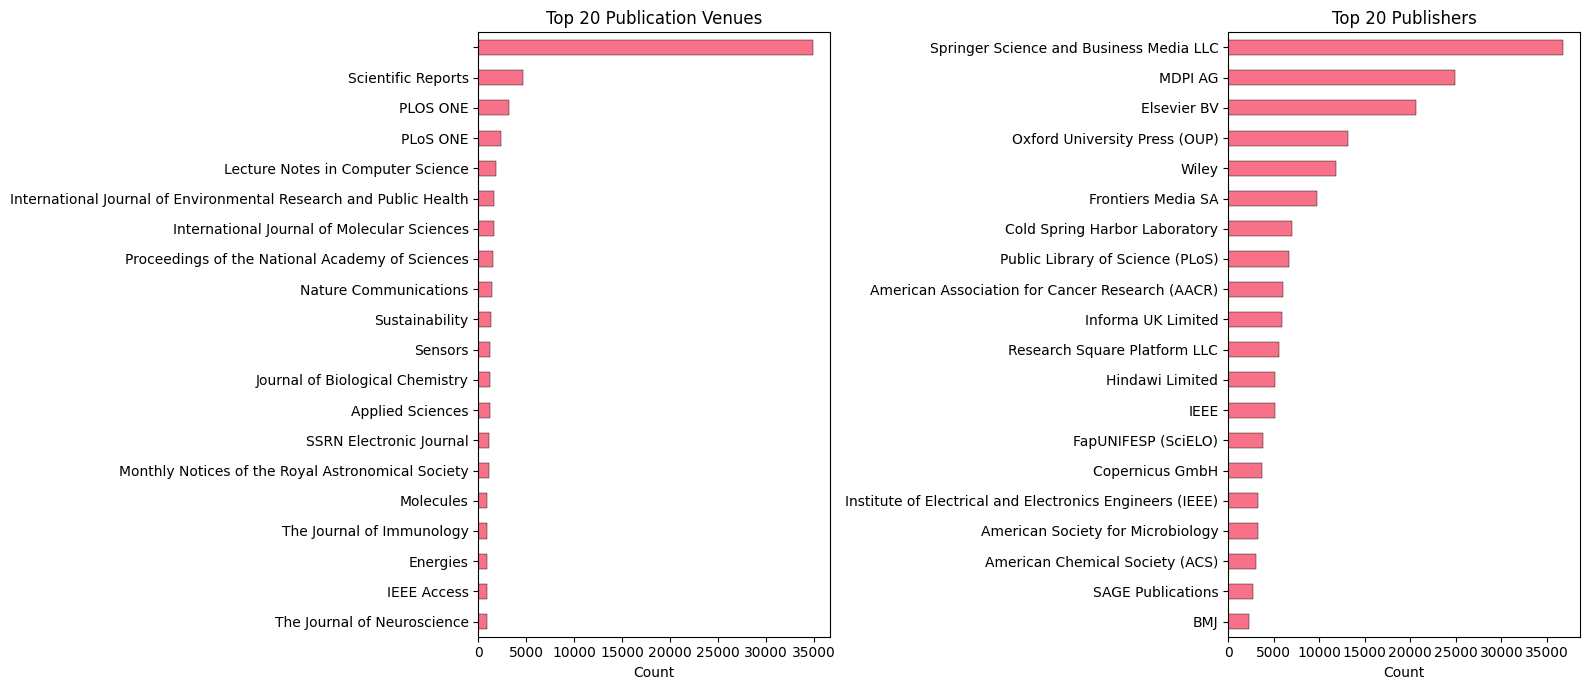

Unique venues: 45,527
Unique publishers: 9,586


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_venues = papers_df['publication_venue'].value_counts().head(20)
top_venues.plot(kind='barh', ax=axes[0], edgecolor='black', linewidth=0.3)
axes[0].set_title("Top 20 Publication Venues")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

top_publishers = papers_df['publisher_name'].value_counts().head(20)
top_publishers.plot(kind='barh', ax=axes[1], edgecolor='black', linewidth=0.3)
axes[1].set_title("Top 20 Publishers")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Unique venues: {papers_df['publication_venue'].nunique():,}")
print(f"Unique publishers: {papers_df['publisher_name'].nunique():,}")

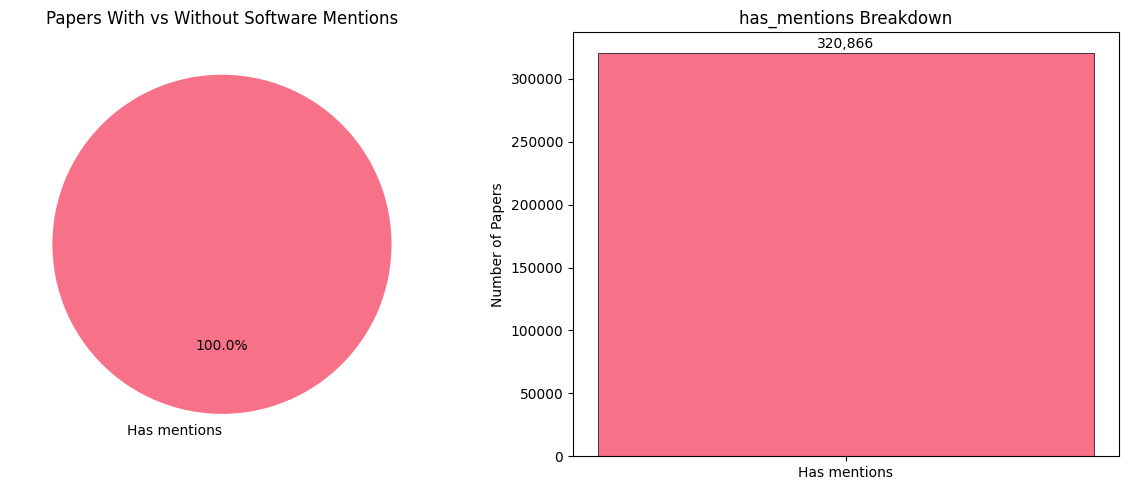

Total papers: 320,866
With mentions: 320,866 (100.0%)
Without mentions: 0 (0.0%)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mention_counts = papers_df['has_mentions'].value_counts()
labels = ['Has mentions' if v else 'No mentions' for v in mention_counts.index]
axes[0].pie(mention_counts, labels=labels, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Papers With vs Without Software Mentions")

axes[1].bar(labels, mention_counts.values, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel("Number of Papers")
axes[1].set_title("has_mentions Breakdown")
for i, v in enumerate(mention_counts.values):
    axes[1].text(i, v + v * 0.01, f"{v:,}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

total = len(papers_df)
with_mentions = mention_counts.get(True, 0)
print(f"Total papers: {total:,}")
print(f"With mentions: {with_mentions:,} ({with_mentions/total*100:.1f}%)")
print(f"Without mentions: {total - with_mentions:,} ({(total - with_mentions)/total*100:.1f}%)")

In [28]:
unique_software_mentions = mentions_df['software_normalized'].value_counts()
unique_software_mentions.head(20)


LaTeX              117252
SPSS                81880
MATLAB              31567
SAS                 25238
ImageJ              24401
code                23140
GraphPad Prism      21401
Excel               21265
Matlab              17829
script              13971
Android             12403
Google              12155
BLAST               11983
survival            11681
Stata               11449
Linux               11369
scripts              9286
SPSS Statistics      7177
ArcGIS               7059
Google Scholar       6807
Name: software_normalized, dtype: int64

## Software Mentions Analysis by Paper


In [29]:
# Group software mentions by paper_id
print("=== SOFTWARE MENTIONS BY PAPER ===")

# Count mentions per paper
mentions_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='mention_count')
print(f"Number of papers with software mentions: {len(mentions_per_paper):,}")

# Show distribution of mentions per paper
print(f"\nMention count statistics:")
print(mentions_per_paper['mention_count'].describe())

# Show papers with most mentions
print(f"\nTop 10 papers by mention count:")
top_papers = mentions_per_paper.nlargest(20, 'mention_count')
print(top_papers)


=== SOFTWARE MENTIONS BY PAPER ===
Number of papers with software mentions: 320,866

Mention count statistics:
count    320866.000000
mean          8.657066
std          63.302443
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max       32162.000000
Name: mention_count, dtype: float64

Top 10 papers by mention count:
        paper_id  mention_count
125535   9286192          32162
128204   9485442           3585
274699  20323662           3148
146310  10830805           3063
297591  22031951           2690
34786    2567414           2417
292229  21627864           1619
74901    5535986           1616
290172  21472294           1575
21163    1564995           1343
222235  16462385           1271
29175    2146144           1270
137177  10160346           1260
209129  15488848           1248
72495    5354066           1197
166532  12345743           1177
70795    5229009           1155
227367  16837963           1118
105729   7821710           1

In [30]:
# Find the specific paper that mentions the most software
most_mentioned_paper = papers_df[papers_df['paper_id'] == 9286192]
columns_to_view = ['title', 'doi']
print(most_mentioned_paper[columns_to_view])    

                                                    title  \
125535  Scalable Model-Based Management of Correlated ...   

                                 doi  
125535  10.1109/icde51399.2021.00123  


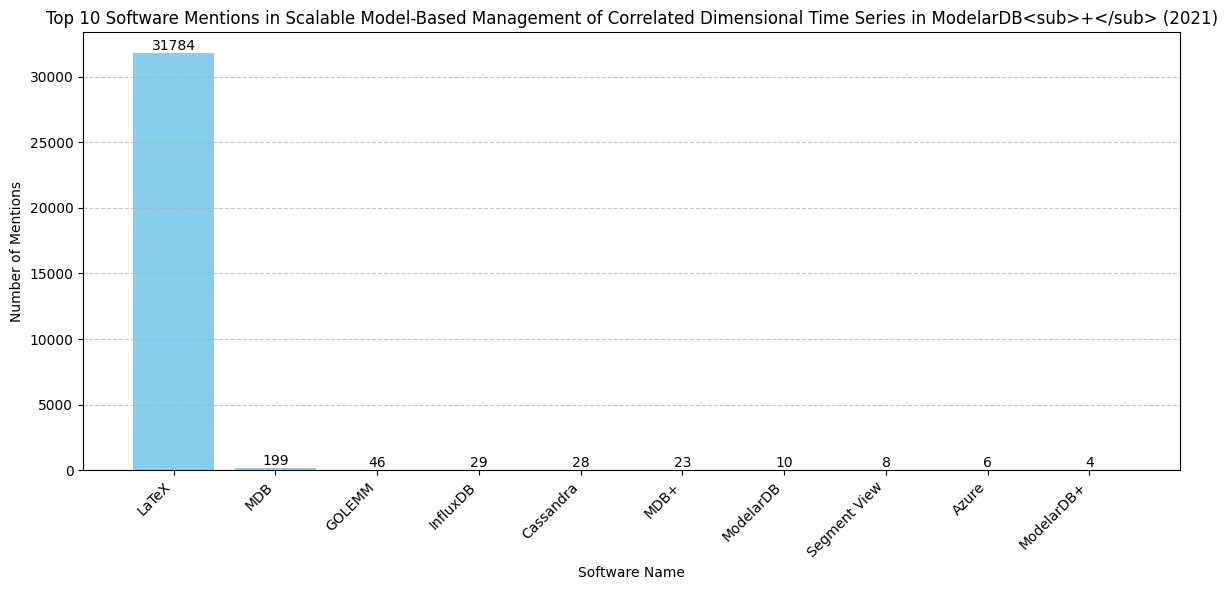

In [34]:
def plot_software_mentions_for_paper(paper_id, top_n=10, figsize=(12, 6), color='skyblue'):
    """
    Create a bar chart showing the top software mentions for a specific paper.
    
    Parameters:
    -----------
    paper_id : int
        The paper ID to analyze
    top_n : int, default 10
        Number of top software to display
    figsize : tuple, default (12, 6)
        Figure size for the plot
    color : str, default 'skyblue'
        Color for the bars
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure object
    """
    # Get the paper info
    paper_info = papers_df[papers_df['paper_id'] == paper_id]
    if len(paper_info) == 0:
        print(f"No paper found with ID {paper_id}")
        return None
    
    # Get software mentions for this paper
    paper_mentions = mentions_df[mentions_df['paper_id'] == paper_id]
    if len(paper_mentions) == 0:
        print(f"No software mentions found for paper {paper_id}")
        return None
    
    # Count mentions by software
    mention_counts = paper_mentions['software_normalized'].value_counts()
    
    # Get top N software
    top_n_mentions = mention_counts.head(top_n)
    
    # Convert to DataFrame for plotting
    plot_df = top_n_mentions.reset_index()
    plot_df.columns = ['Software', 'Mentions']
    
    # Create the plot
    plt.figure(figsize=figsize)
    bars = plt.bar(plot_df['Software'], plot_df['Mentions'], color=color)
    
    # Add labels and title
    paper_title = paper_info['title'].iloc[0] if 'title' in paper_info.columns else f"Paper {paper_id}"
    paper_title = str(paper_title).replace('$', r'\$')
    plt.title(f'Top {top_n} Software Mentions in {paper_title} ({paper_info["published_year"].iloc[0]})') 
    plt.xlabel('Software Name')
    plt.ylabel('Number of Mentions')
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, 
                 int(yval), ha='center', va='bottom', fontsize=10)
    
    # Add grid and adjust layout
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    

# Usage examples:
# Plot for paper 7491989
plot_software_mentions_for_paper(9286192)
plt.show()



--- #1: paper_id=9286192.0  mentions=32162.0 ---
Title: Scalable Model-Based Management of Correlated Dimensional Time Series in ModelarDB<sub>+</sub>


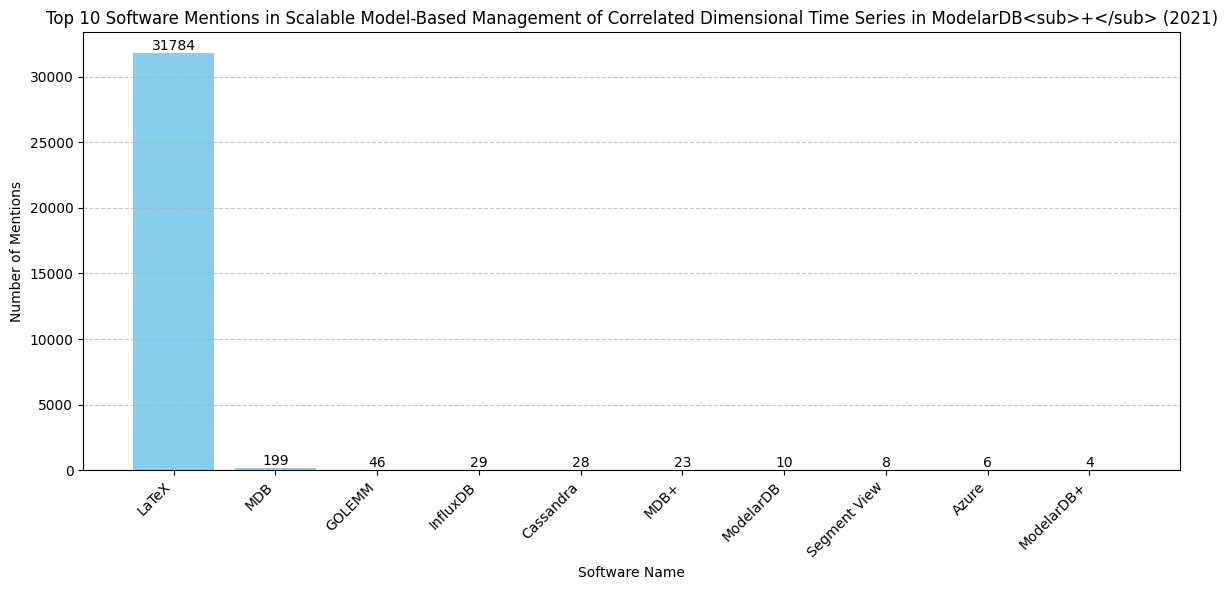


--- #2: paper_id=9485442.0  mentions=3585.0 ---
Title: Worst-Case Delay Bounds in Time-Sensitive Networks With Packet Replication and Elimination


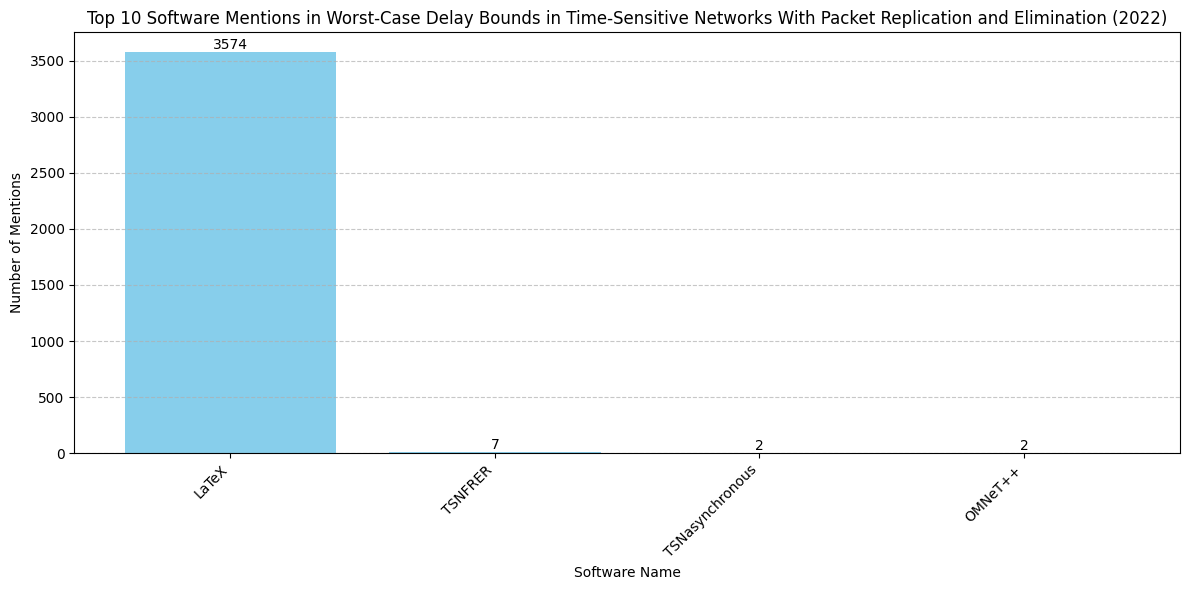


--- #3: paper_id=20323662.0  mentions=3148.0 ---
Title: Proceedings of the 21st Python in Science Conference


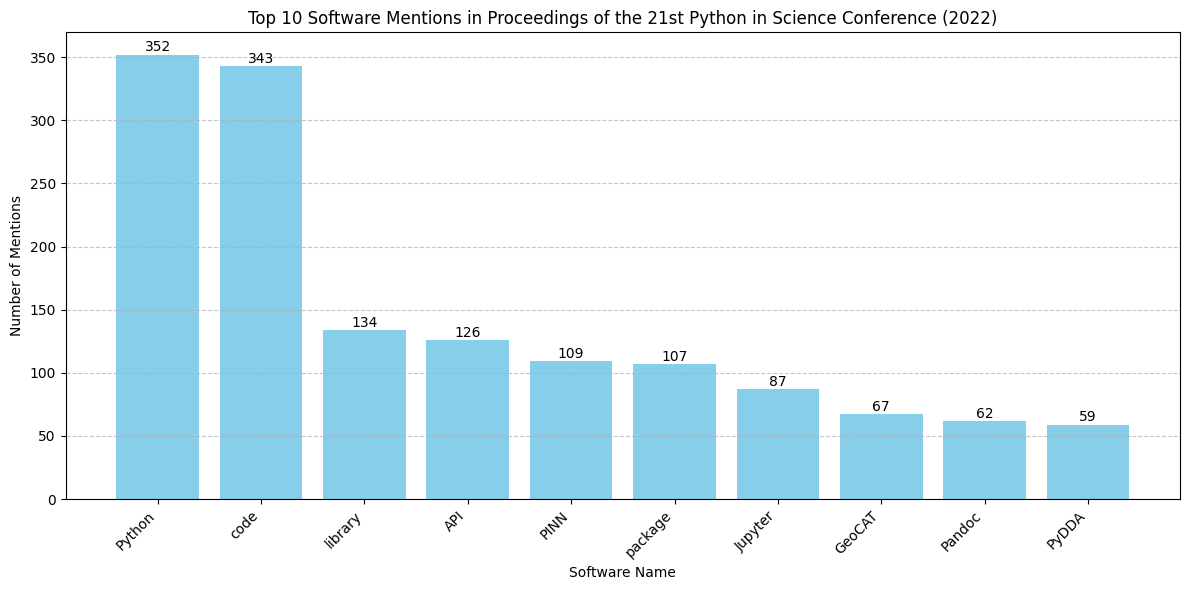


--- #4: paper_id=10830805.0  mentions=3063.0 ---
Title: Search for a heavy Higgs boson decaying into a Z boson and another heavy Higgs boson in the $$\ell \ell bb$$ and $$\ell \ell WW$$ final states in pp collisions at $$\sqrt{s}=13$$ $$\text {TeV}$$ with the ATLAS detector


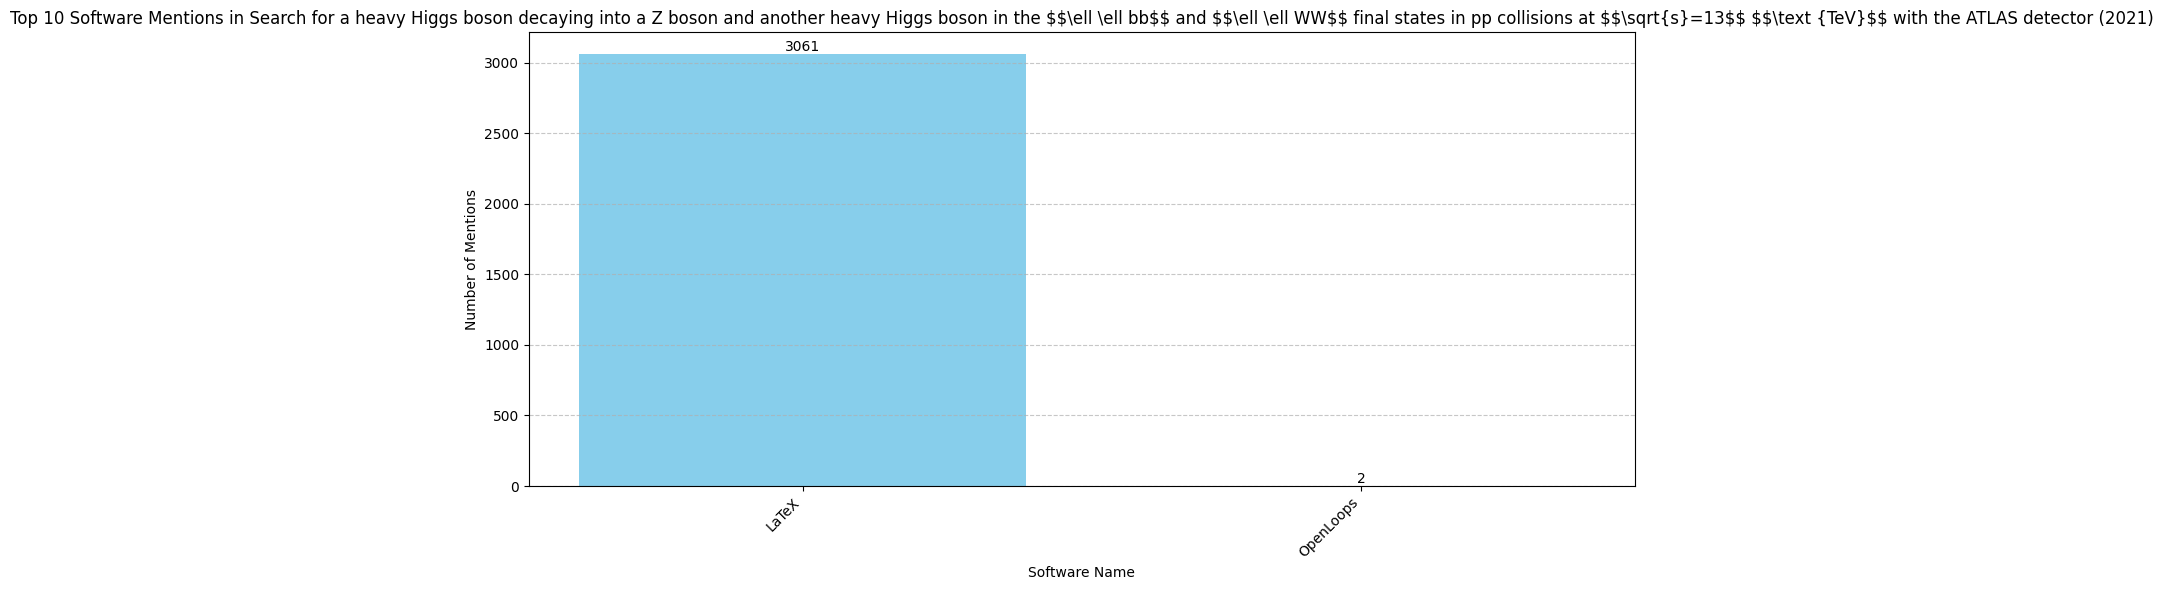


--- #5: paper_id=22031951.0  mentions=2690.0 ---
Title: Space-Efficient Manifest Contracts


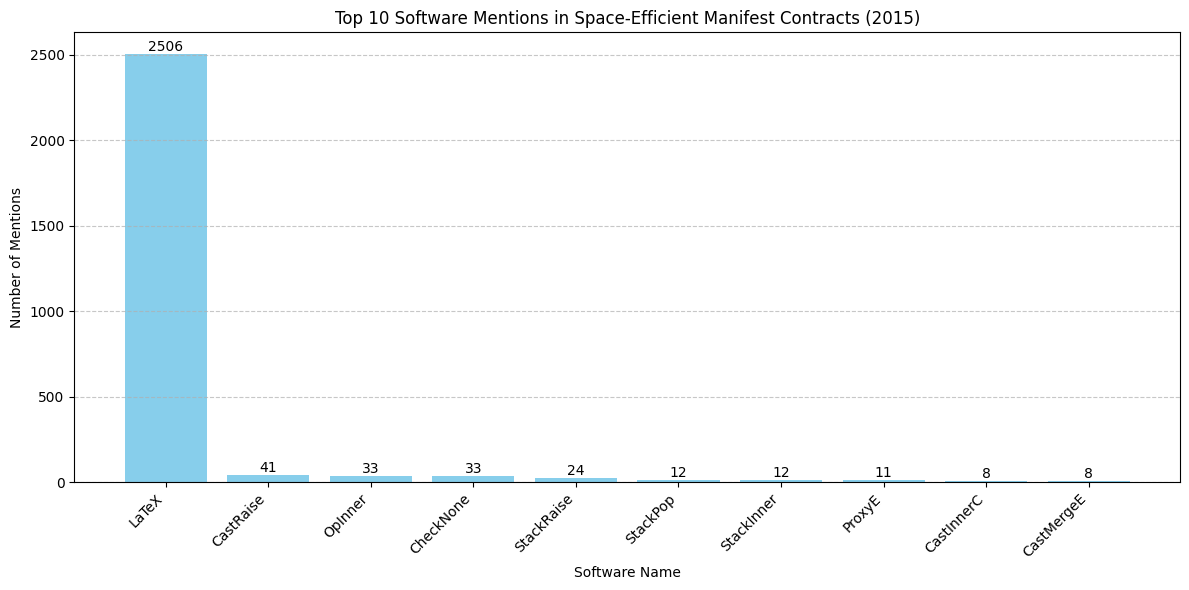

In [35]:
n_papers_to_show = 5
for rank, row in top_papers.head(n_papers_to_show).iterrows():
    pid = row['paper_id']
    count = row['mention_count']
    title_row = papers_df.loc[papers_df['paper_id'] == pid, 'title']
    title = title_row.values[0] if len(title_row) > 0 else "Unknown"
    print(f"\n--- #{top_papers.index.get_loc(rank)+1}: paper_id={pid}  mentions={count} ---")
    print(f"Title: {title}")
    plot_software_mentions_for_paper(pid)
    plt.show()

# The paper that has the most mentions of software overall is called "Multi-Order Networks for Action Unit Detection" (2022) and from the graph you can see that there's the detection of 4498 instances of the LaTeX software. This is interesting because searching through the PDF document of the paper there was no explicit mention of LaTeX as a software. It's most likely the machine learning model detected their typing format as LaTeX, as they do have several figures used to show their math. 

# The rest of the software mentions found in this paper were of a reasonable count. Upon using the search function in the pdf itself, the counts displayed above were only slightly off the amount found in the search. VGGFace2 found to be exactly 2.

In [ ]:
second_paper = top_papers['paper_id'].iloc[1]
print(f"2nd paper: {second_paper}")


2nd paper: 21068065


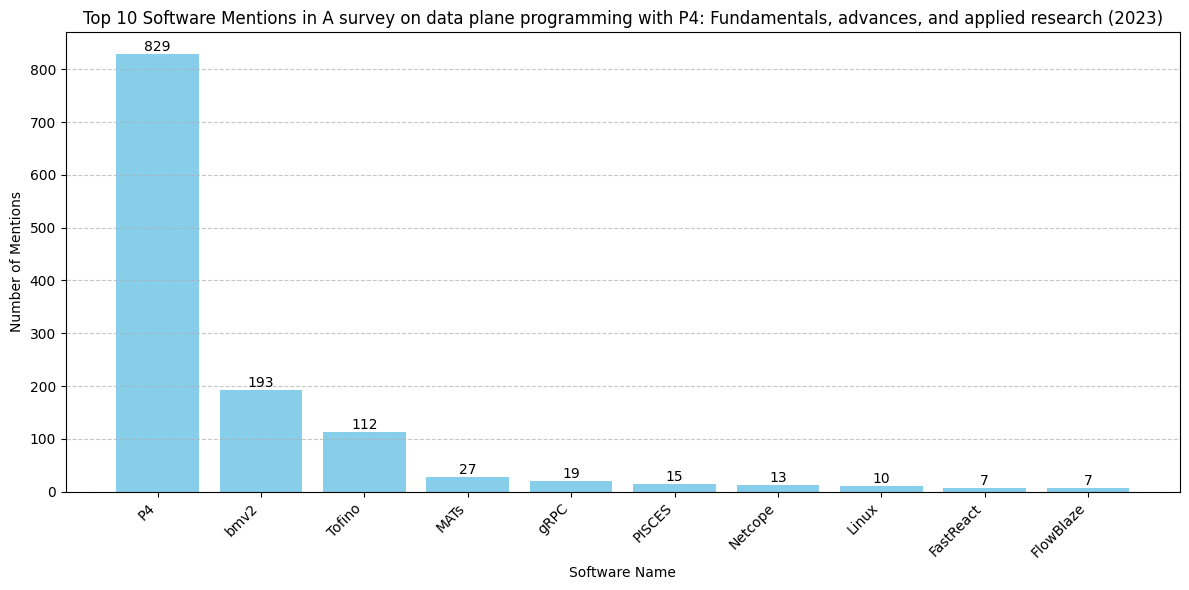

In [85]:
plot_software_mentions_for_paper(second_paper)
plt.show()


# The 2nd paper with the most software mentions overall is "A Survey on data plane programming with P4: Fundamentals, advances, and applied research (2023). The top software was P4 which makes sense because that's mainly what the paper is about. When searching the pdf it registers 1,441 mentions of P4 which is interesting as the graph suggests 829 mentions were found which may be something to look further into.

# The rest of the software mentions found in this paper either matched exactly or very closely to however many I found when looking at the pdf myself

In [86]:
third_paper = top_papers['paper_id'].iloc[2]
print(f"3rd paper: {third_paper}")


3rd paper: 19357132


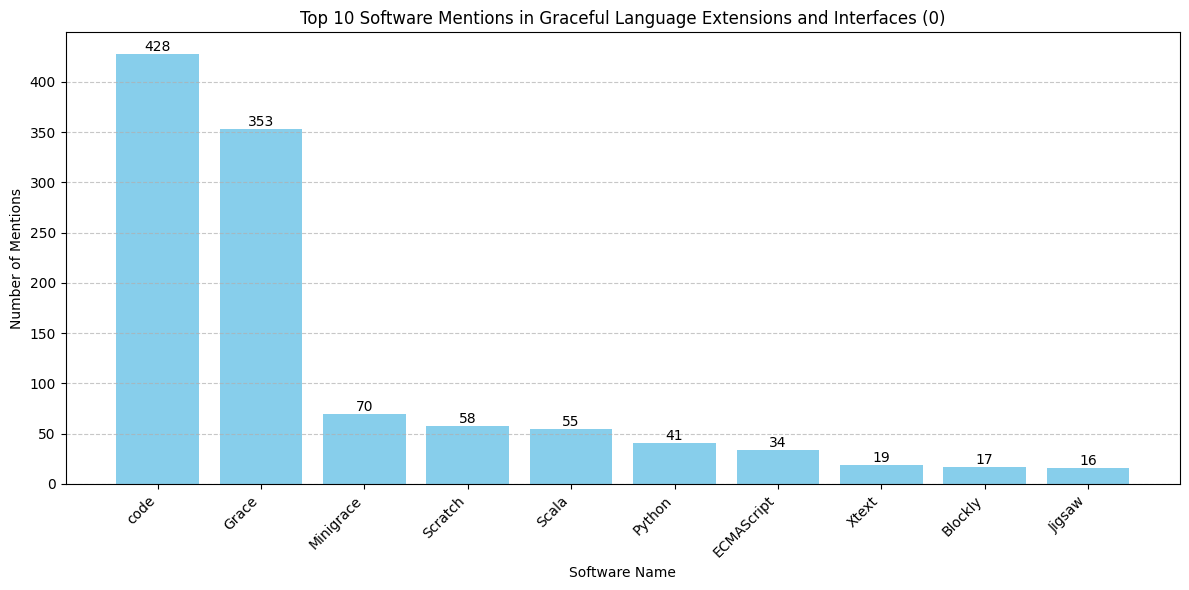

In [87]:
plot_software_mentions_for_paper(third_paper)
plt.show()

# The 3rd paper with the most software mentions is a thesis titled "Graceful Language Extensions and Interfaces" which primarily discusses a programming language named 'Grace' which is aimed at education. Upon looking at the software in the graph above the counts were roughly similar if not the same as the count I found by looking at the pdf.

# I did notice though that there were several instances where code was mentioned or used but not in a way that is explicitly related to software unless the model detected any mention of code as software. This may be something worth looking into if this is the case.

In [88]:
fourth_paper = top_papers['paper_id'].iloc[3]
print(f"4th paper: {fourth_paper}")

4th paper: 11828498


In [105]:
sixth_paper = top_papers['paper_id'].iloc[5]
print(f"6th paper: {sixth_paper}")

6th paper: 10220302


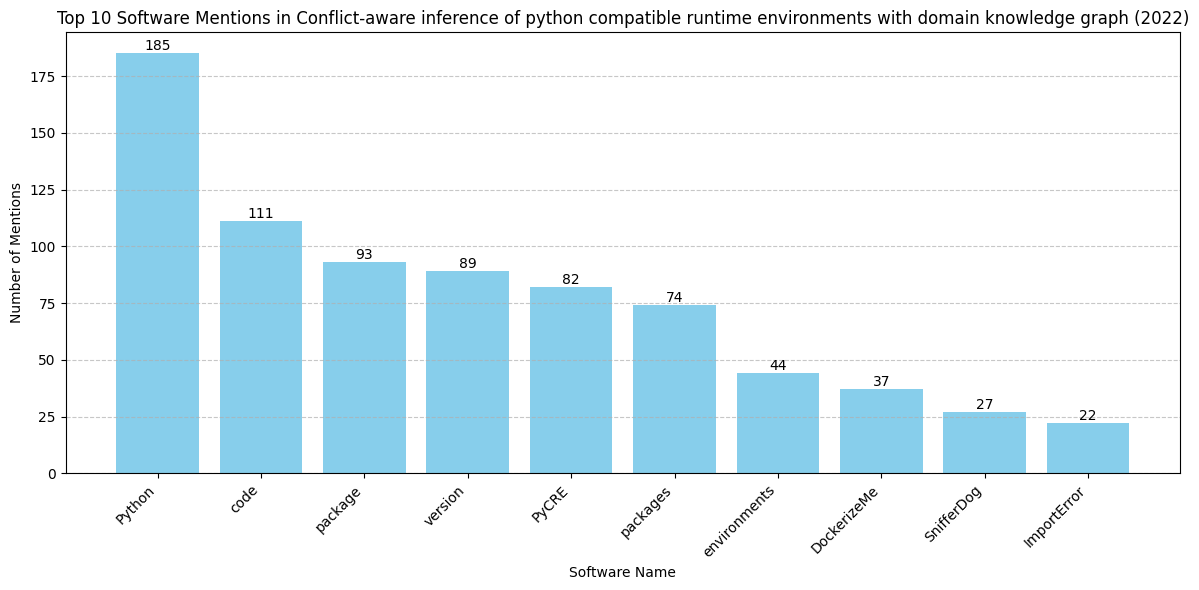

In [93]:
plot_software_mentions_for_paper(sixth_paper)
plt.show()

In [94]:
seventh_paper = top_papers['paper_id'].iloc[6]
print(f"7th paper: {seventh_paper}")

7th paper: 4062782


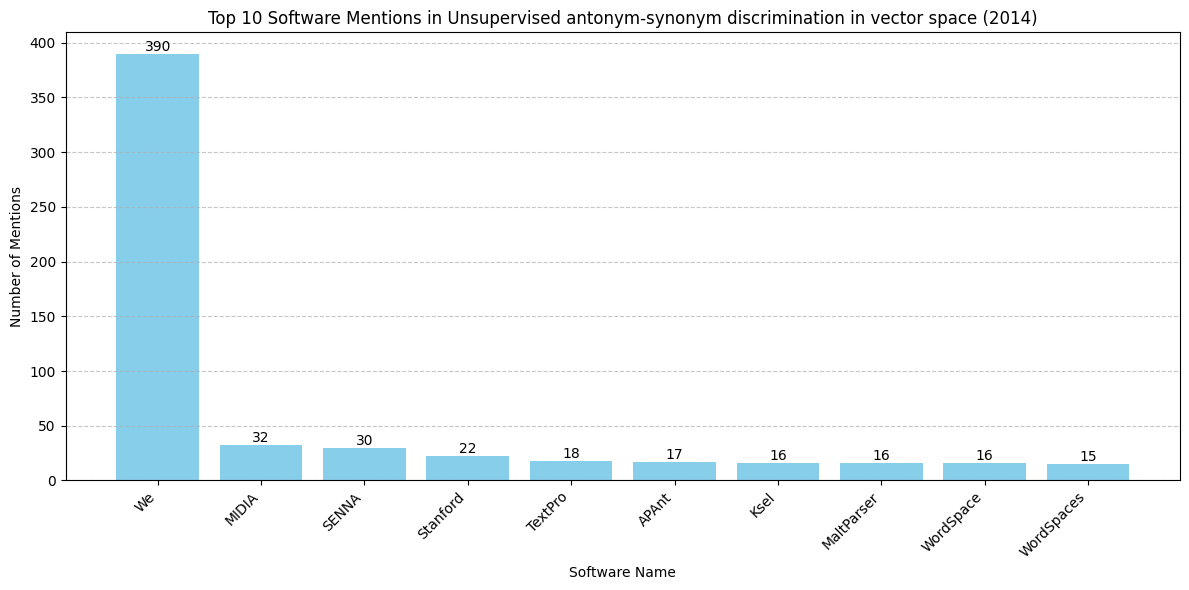

In [104]:
plot_software_mentions_for_paper(seventh_paper)
plt.show()

In [96]:
eigth_paper = top_papers['paper_id'].iloc[7]
print(f"8th paper: {eigth_paper}")

8th paper: 8894786


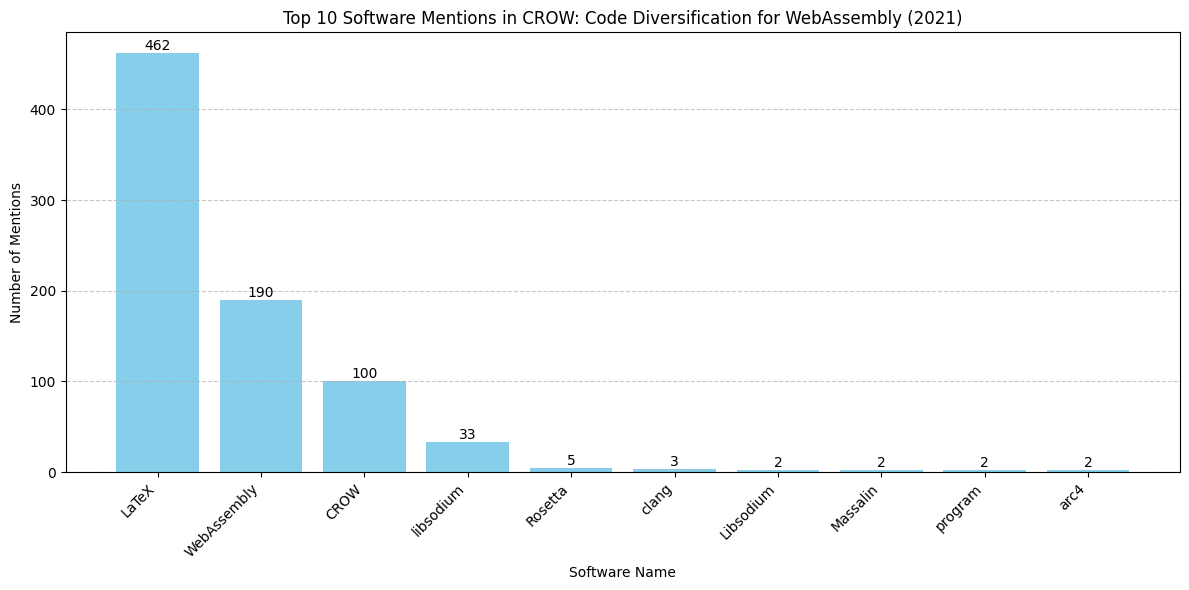

In [97]:
plot_software_mentions_for_paper(eigth_paper)
plt.show()

In [98]:
ninth_paper = top_papers['paper_id'].iloc[8]
print(f"9th paper: {ninth_paper}")

9th paper: 19407776


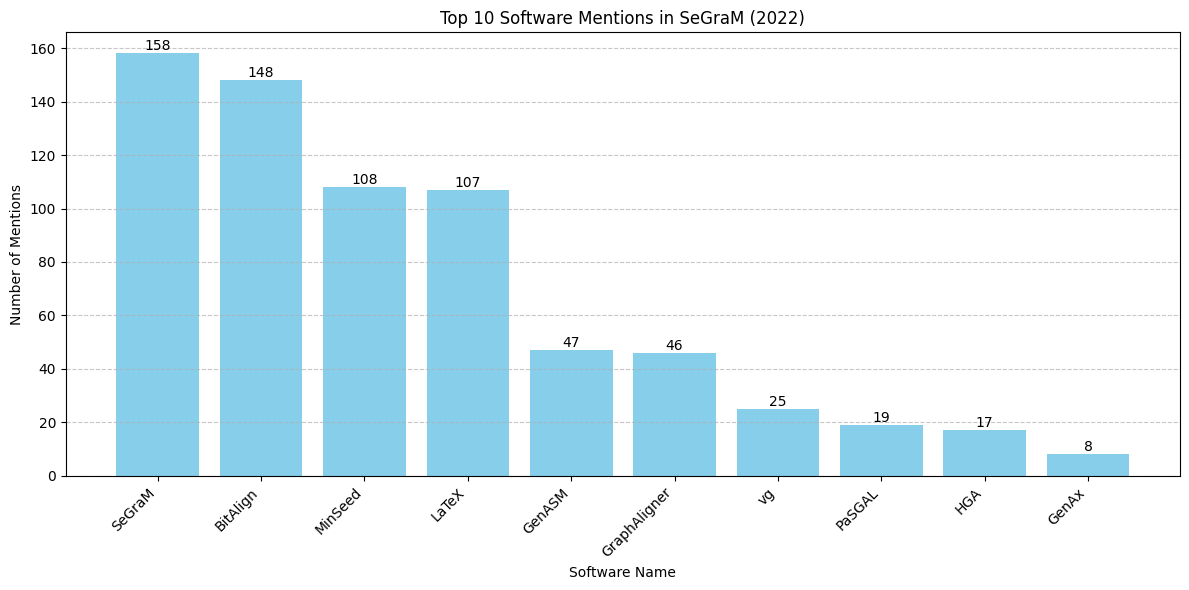

In [99]:
plot_software_mentions_for_paper(ninth_paper)
plt.show()

In [100]:
tenth_paper = top_papers['paper_id'].iloc[9]
print(f"10th paper: {tenth_paper}")

10th paper: 7630708


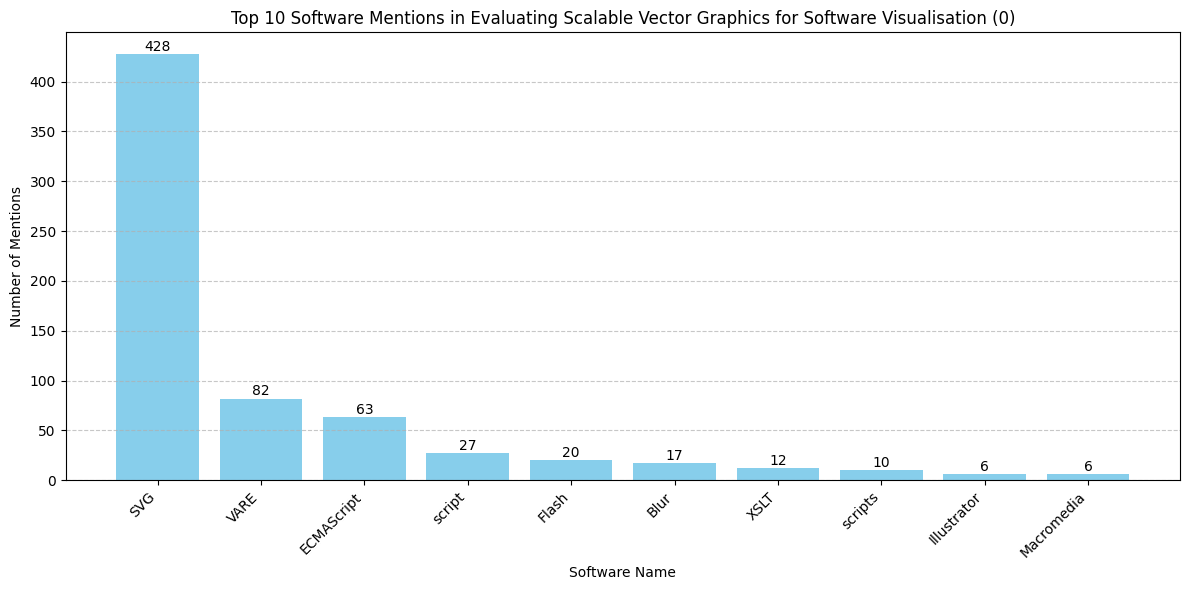

In [101]:
plot_software_mentions_for_paper(tenth_paper)
plt.show()

In [107]:
eleventh_paper = top_papers['paper_id'].iloc[10]
print(f"11th paper: {eleventh_paper}")

11th paper: 4946447


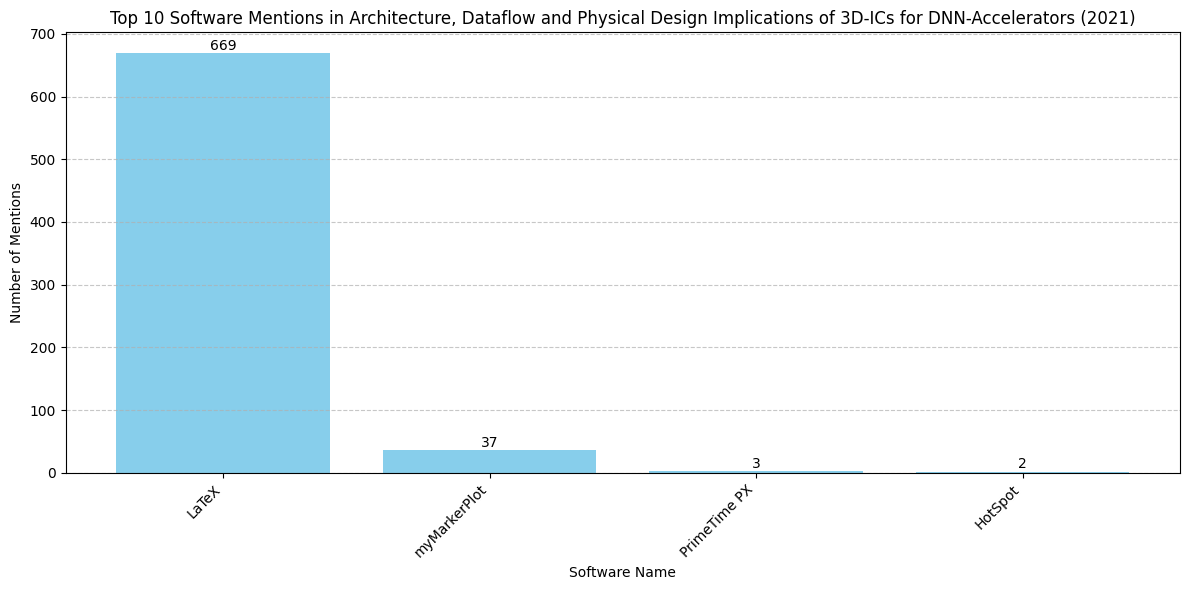

In [108]:
plot_software_mentions_for_paper(eleventh_paper)
plt.show()

In [109]:
twelfth_paper = top_papers['paper_id'].iloc[11]
print(f"12th paper: {twelfth_paper}")

12th paper: 17478202


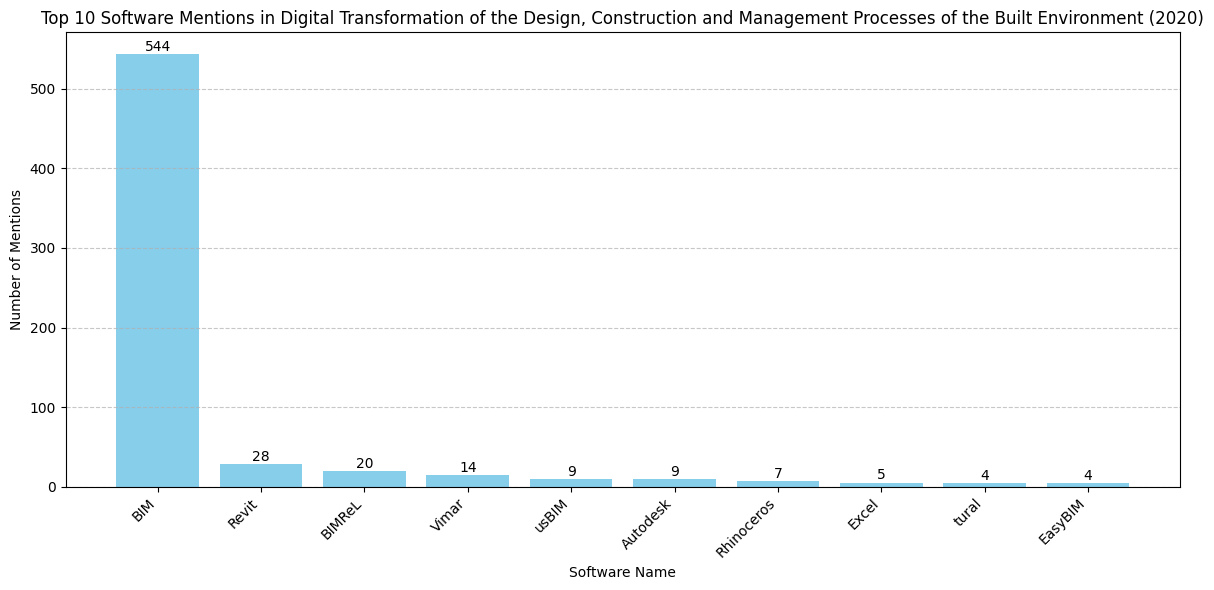

In [110]:
plot_software_mentions_for_paper(twelfth_paper)
plt.show()

In [111]:
thirteenth_paper = top_papers['paper_id'].iloc[12]
print(f"13th paper: {thirteenth_paper}")

13th paper: 1878645


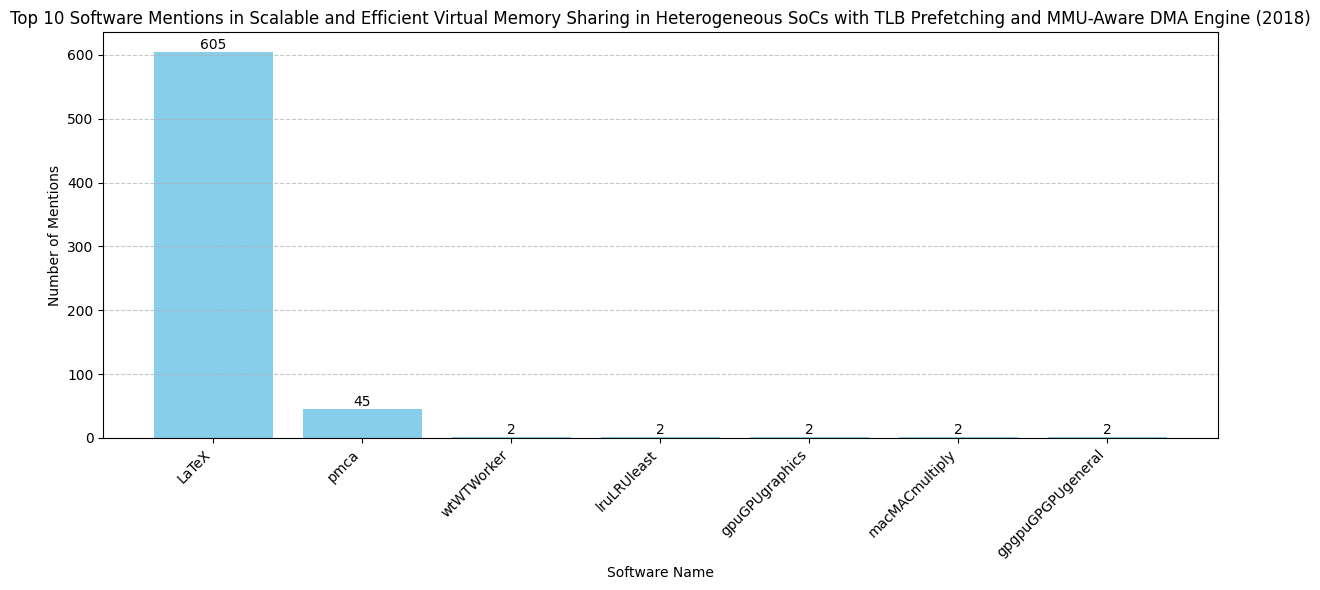

In [112]:
plot_software_mentions_for_paper(thirteenth_paper)
plt.show()

In [113]:
fourteenth_paper = top_papers['paper_id'].iloc[13]
print(f"14th paper: {fourteenth_paper}")

14th paper: 18618787


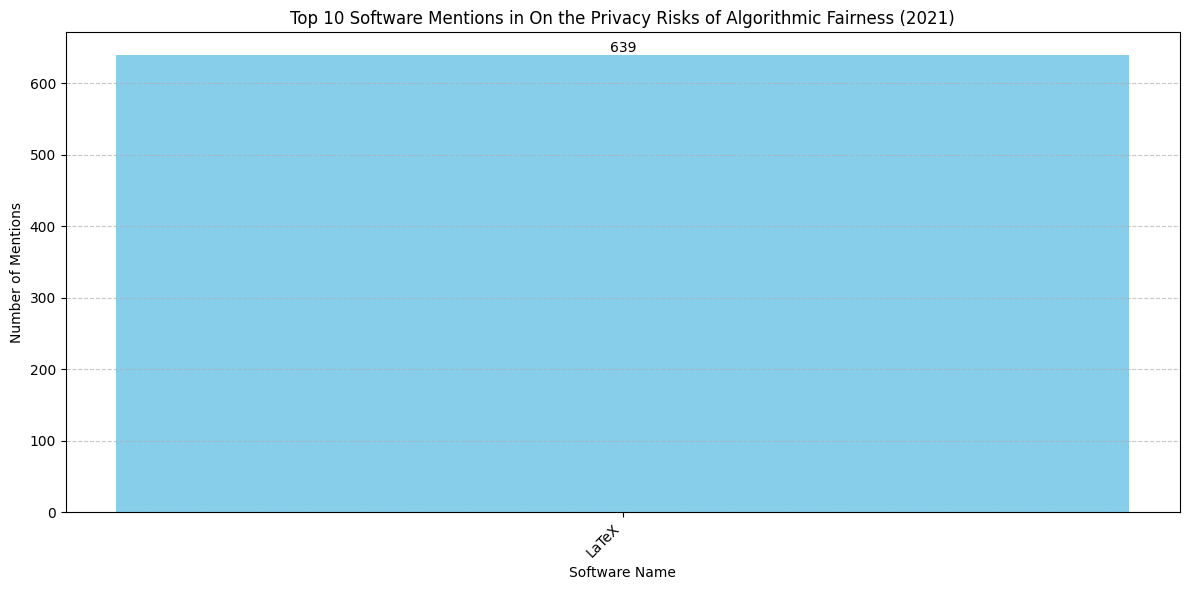

In [114]:
plot_software_mentions_for_paper(fourteenth_paper)
plt.show()

In [115]:
fifteenth_paper = top_papers['paper_id'].iloc[14]
print(f"15th paper: {fifteenth_paper}")

15th paper: 9132872


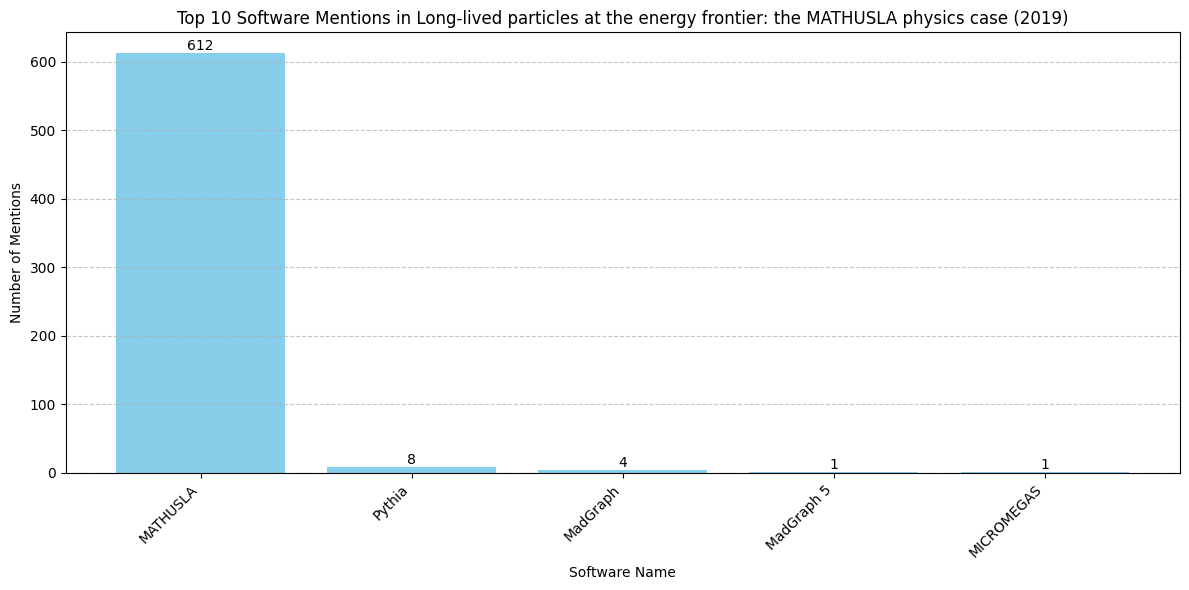

In [116]:
plot_software_mentions_for_paper(fifteenth_paper)
plt.show()

In [117]:
sixteenth_paper = top_papers['paper_id'].iloc[15]
print(f"16th paper: {sixteenth_paper}")

16th paper: 16557688


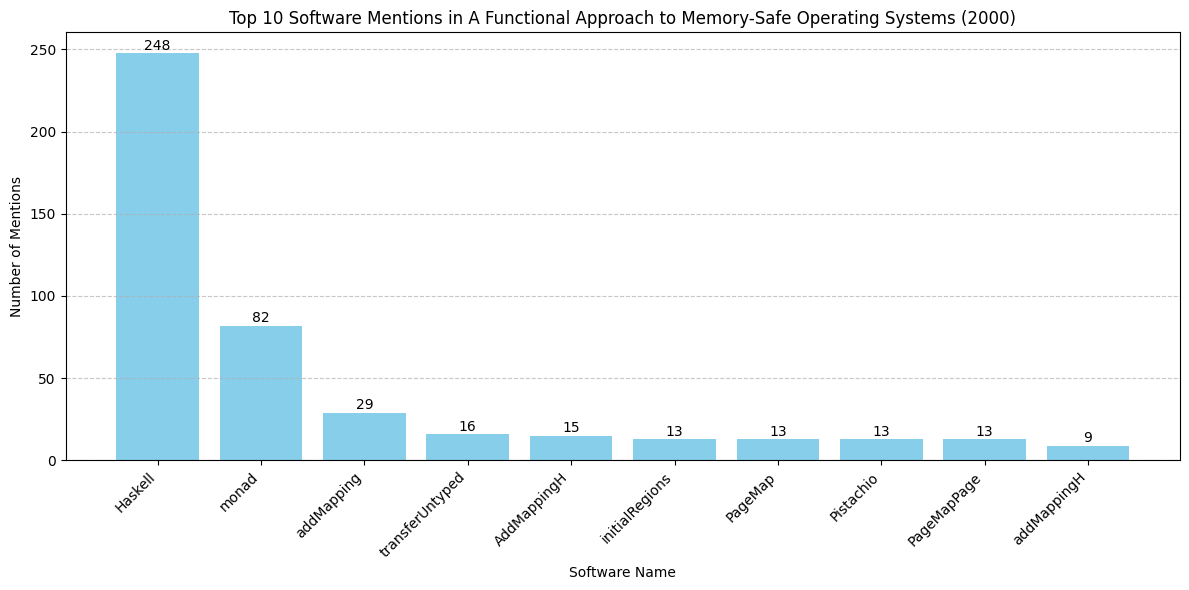

In [118]:
plot_software_mentions_for_paper(sixteenth_paper)
plt.show()

In [119]:
seventeenth_paper = top_papers['paper_id'].iloc[16]
print(f"17th paper: {seventeenth_paper}")

17th paper: 5900053


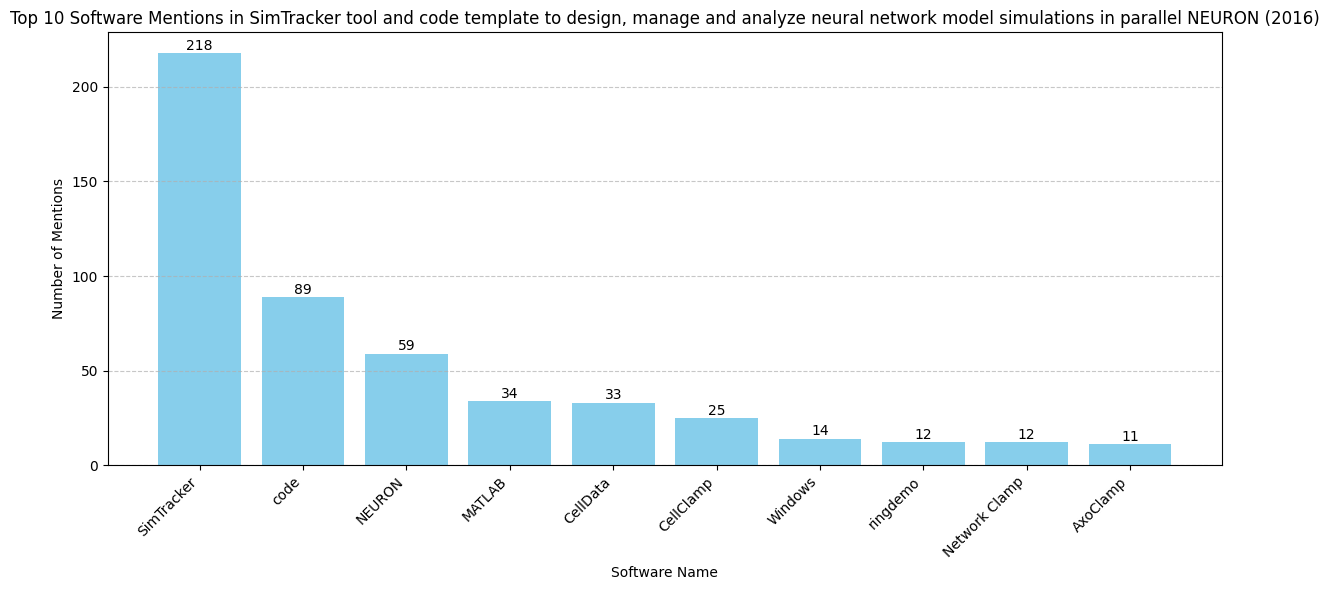

In [120]:
plot_software_mentions_for_paper(seventeenth_paper)
plt.show()

In [121]:
eighteenth_paper = top_papers['paper_id'].iloc[17]
print(f"18th paper: {eighteenth_paper}")

18th paper: 14935616


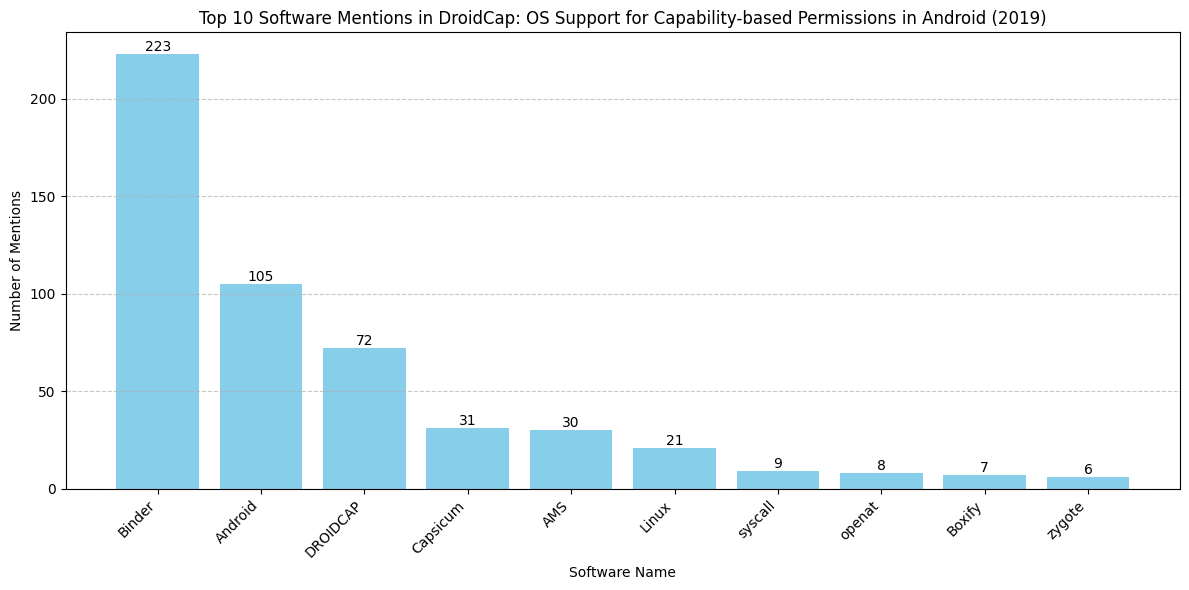

In [122]:
plot_software_mentions_for_paper(eighteenth_paper)
plt.show()

In [123]:
nineteenth_paper = top_papers['paper_id'].iloc[18]
print(f"19th paper: {nineteenth_paper}")

19th paper: 6989309


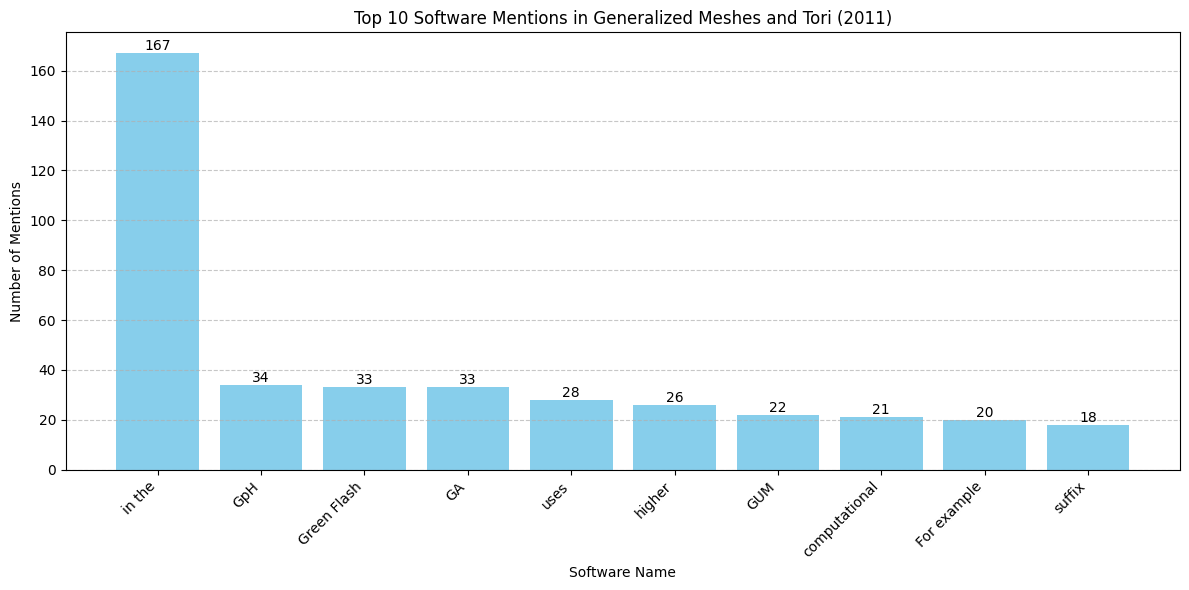

In [124]:
plot_software_mentions_for_paper(nineteenth_paper)
plt.show()

In [125]:
twentieth_paper = top_papers['paper_id'].iloc[19]
print(f"20th paper: {twentieth_paper}")

20th paper: 13372447


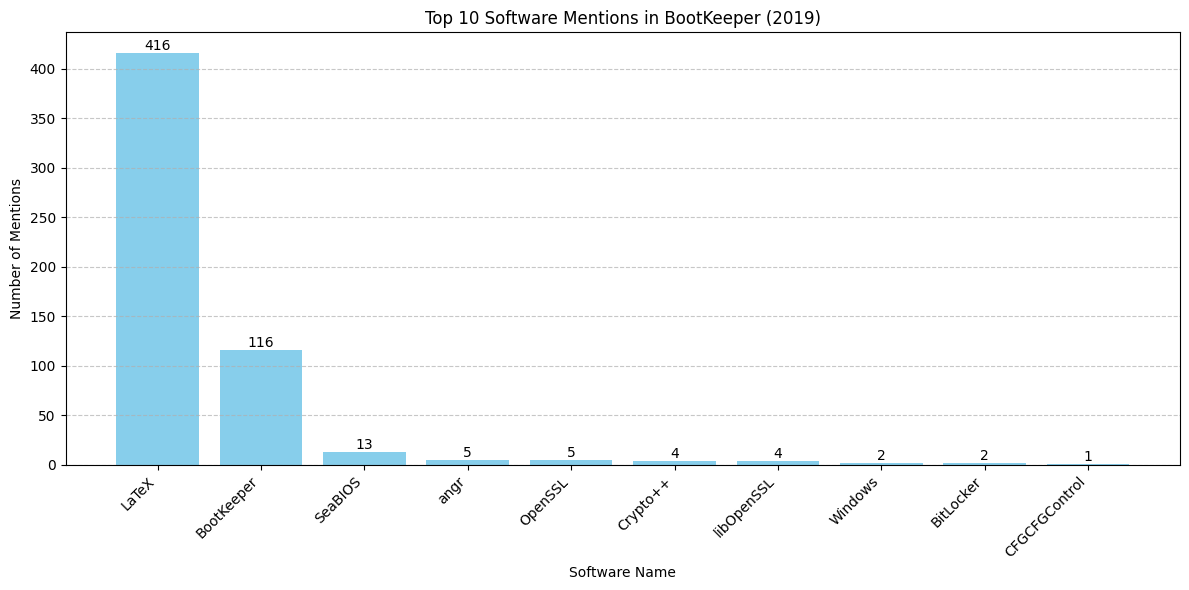

In [126]:
plot_software_mentions_for_paper(twentieth_paper)
plt.show()

### Mention Frequency Distribution & Long-Tail Analysis

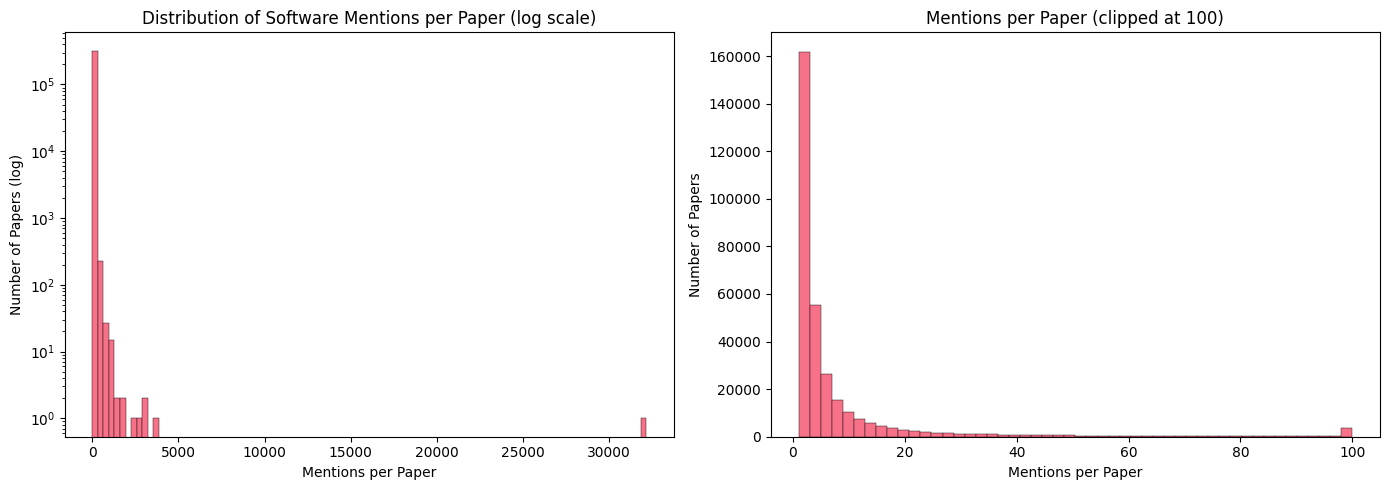

Mentions-per-paper statistics:
count    320866.000000
mean          8.657066
std          63.302443
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max       32162.000000
Name: mention_count, dtype: float64


In [36]:
mentions_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='mention_count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mentions_per_paper['mention_count'], bins=100, edgecolor='black', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_title("Distribution of Software Mentions per Paper (log scale)")
axes[0].set_xlabel("Mentions per Paper")
axes[0].set_ylabel("Number of Papers (log)")

axes[1].hist(mentions_per_paper['mention_count'].clip(upper=100), bins=50, edgecolor='black', linewidth=0.3)
axes[1].set_title("Mentions per Paper (clipped at 100)")
axes[1].set_xlabel("Mentions per Paper")
axes[1].set_ylabel("Number of Papers")

plt.tight_layout()
plt.show()

print(f"Mentions-per-paper statistics:")
print(mentions_per_paper['mention_count'].describe())

Total unique software names (normalized): 221,434
Total mentions: 2,777,758

Software names accounting for 80% of mentions: 22,308 (10.07% of unique names)
Software names accounting for 90% of mentions: 53,212 (24.03% of unique names)


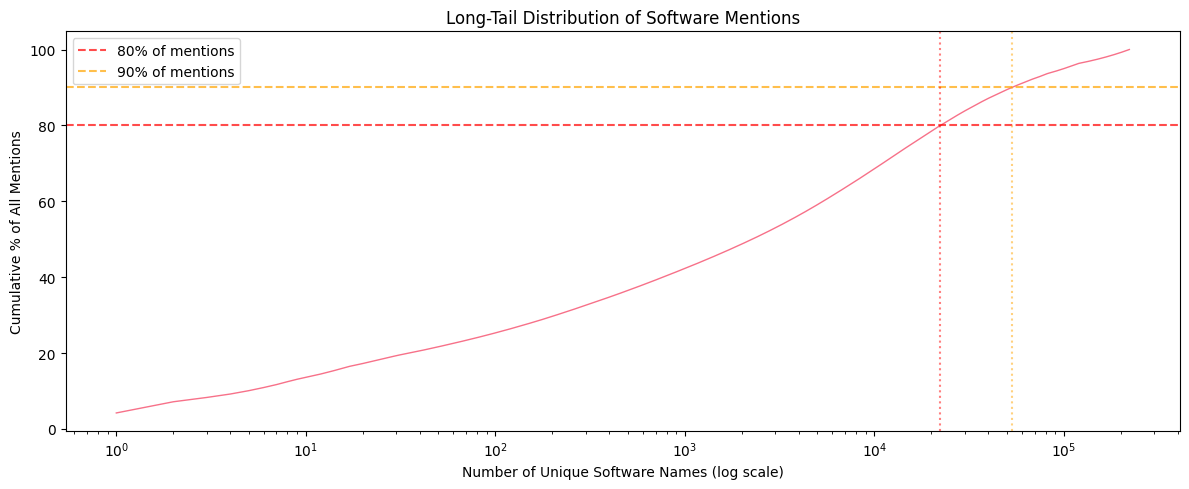

In [37]:
software_freq = mentions_df['software_normalized'].value_counts()
total_mentions = software_freq.sum()

cumulative = software_freq.cumsum()
cumulative_pct = cumulative / total_mentions * 100

threshold_80 = (cumulative_pct <= 80).sum()
threshold_90 = (cumulative_pct <= 90).sum()

print(f"Total unique software names (normalized): {len(software_freq):,}")
print(f"Total mentions: {total_mentions:,}")
print(f"\nSoftware names accounting for 80% of mentions: {threshold_80:,} ({threshold_80/len(software_freq)*100:.2f}% of unique names)")
print(f"Software names accounting for 90% of mentions: {threshold_90:,} ({threshold_90/len(software_freq)*100:.2f}% of unique names)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(cumulative_pct) + 1), cumulative_pct.values, linewidth=1)
ax.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% of mentions')
ax.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% of mentions')
ax.axvline(x=threshold_80, color='r', linestyle=':', alpha=0.5)
ax.axvline(x=threshold_90, color='orange', linestyle=':', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel("Number of Unique Software Names (log scale)")
ax.set_ylabel("Cumulative % of All Mentions")
ax.set_title("Long-Tail Distribution of Software Mentions")
ax.legend()
plt.tight_layout()
plt.show()

### Normalized vs Raw Name Comparison & Field Availability

In [38]:
raw_per_normalized = (
    mentions_df.groupby('software_normalized')['software_raw']
    .nunique()
    .sort_values(ascending=False)
)
print("Normalized names with the most distinct raw variants:")
print(raw_per_normalized.head(15))
print(f"\nMedian raw variants per normalized name: {raw_per_normalized.median():.0f}")
print(f"Mean raw variants per normalized name: {raw_per_normalized.mean():.1f}")

print(f"\nTotal unique raw names: {mentions_df['software_raw'].nunique():,}")
print(f"Total unique normalized names: {mentions_df['software_normalized'].nunique():,}")
print(f"Compression ratio: {mentions_df['software_raw'].nunique() / mentions_df['software_normalized'].nunique():.2f}x")

Normalized names with the most distinct raw variants:
software_normalized
Statistical Package for the Social Sciences           21
Statistical Package for the Social Sciences (SPSS)    21
Vienna ab initio simulation package (VASP)            19
Statistical Package for Social Sciences               18
Basic Local Alignment Search Tool (BLAST)             17
Statistical Package for the Social Sciences (SPSS     16
Statistical Package for Social Science (SPSS)         14
Vienna Ab initio Simulation Package (VASP)            13
Statistical Package for Social Sciences (SPSS         13
Statistical Package for the Social Science (SPSS)     13
SPSS (Statistical Package for the Social Sciences)    12
Ingenuity Pathway Analysis                            12
CLC Genomics Workbench                                12
Google Scholar                                        11
Vienna Ab Initio Simulation Package (VASP)            10
Name: software_raw, dtype: int64

Median raw variants per normalized na

In [ ]:
optional_fields = ['version_raw', 'version_normalized', 'publisher_raw',
                   'language_raw', 'url_raw', 'url_normalized']

total = len(mentions_df)
availability = []
for col in optional_fields:
    if col in mentions_df.columns:
        non_null = mentions_df[col].notna().sum()
        non_empty = (mentions_df[col].notna() & (mentions_df[col] != '')).sum()
        availability.append({
            'field': col,
            'non_null': non_null,
            'non_null_pct': non_null / total * 100,
            'non_empty': non_empty,
            'non_empty_pct': non_empty / total * 100
        })

avail_df = pd.DataFrame(availability)
display(avail_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(avail_df['field'], avail_df['non_empty_pct'], edgecolor='black', linewidth=0.3)
ax.set_xlabel("% of mentions with non-empty value")
ax.set_title("Optional Field Availability in Mentions Table")
ax.set_xlim(0, 100)
for i, row in avail_df.iterrows():
    ax.text(row['non_empty_pct'] + 0.5, i, f"{row['non_empty_pct']:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [53]:
# Find most frequently mentioned software
print("=== MOST FREQUENTLY MENTIONED SOFTWARE ===")

# Count mentions by software (using normalized names for cleaner results)
software_counts = mentions_df['software_normalized'].value_counts().head(20)
print("Top 20 most mentioned software:")
print(software_counts)

# Also show raw software names for comparison
print(f"\nTop 10 raw software names:")
raw_software_counts = mentions_df['software_raw'].value_counts().head(10)
print(raw_software_counts)


=== MOST FREQUENTLY MENTIONED SOFTWARE ===
Top 20 most mentioned software:
LaTeX              20049
SPSS               15850
MATLAB              6126
ImageJ              4997
SAS                 4863
Excel               4622
GraphPad Prism      4183
code                4167
Matlab              3750
Android             3044
survival            2700
Stata               2536
script              2339
BLAST               2329
Google              2293
Linux               2135
scripts             1642
software            1437
SPSS Statistics     1395
Google Scholar      1363
Name: software_normalized, dtype: int64

Top 10 raw software names:
LaTeX             20049
SPSS              15845
MATLAB             6112
ImageJ             4991
SAS                4860
Excel              4618
code               4167
GraphPad Prism     4006
Matlab             3745
Android            3042
Name: software_raw, dtype: int64


In [ ]:
top_normalized = raw_per_normalized.head(4).index.tolist()

raw_variants = (
    mentions_df[mentions_df['software_normalized'].isin(top_normalized)]
    .groupby(['software_normalized', 'software_raw'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(2, 2, figsize=(22, 24))
axes = axes.flatten()

for idx, norm_name in enumerate(top_normalized):
    ax = axes[idx]
    variants = (
        raw_variants[raw_variants['software_normalized'] == norm_name]
        .sort_values('count', ascending=True)
        .tail(15)
    )
    bars = ax.barh(range(len(variants)), variants['count'], edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(variants)))
    ax.set_yticklabels(variants['software_raw'], fontsize=10)
    safe_title = norm_name.replace('$', r'\$')
    ax.set_title(f'Normalized: "{safe_title}"', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Number of Mentions', fontsize=10)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + w * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', va='center', fontsize=8)
    ax.margins(x=0.15)

plt.suptitle('Raw Name Variants for Top 4 Normalized Software Names\n(top 15 variants each)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Function to analyze specific software mentions
def analyze_software_mentions(software_name, use_normalized=True):
    """
    Analyze mentions of a specific software across papers
    """
    if use_normalized:
        software_mentions = mentions_df[mentions_df['software_normalized'] == software_name]
    else:
        software_mentions = mentions_df[mentions_df['software_raw'] == software_name]
    
    if len(software_mentions) == 0:
        print(f"No mentions found for '{software_name}'")
        return None
    
    # Count mentions per paper for this software
    mentions_by_paper = software_mentions.groupby('paper_id').size().reset_index(name='mention_count')
    
    print(f"=== ANALYSIS FOR '{software_name}' ===")
    print(f"Total mentions: {len(software_mentions):,}")
    print(f"Number of papers mentioning it: {len(mentions_by_paper):,}")
    print(f"Average mentions per paper: {mentions_by_paper['mention_count'].mean():.2f}")
    print(f"Max mentions in a single paper: {mentions_by_paper['mention_count'].max()}")
    
    # Show papers with most mentions of this software
    print(f"\nPapers with most mentions of '{software_name}':")
    top_papers = mentions_by_paper.nlargest(10, 'mention_count')
    print(top_papers)
    
    return mentions_by_paper

# Run Example of function
example_analysis = analyze_software_mentions('LaTeX')

=== ANALYSIS FOR 'LaTeX' ===
Total mentions: 20,049
Number of papers mentioning it: 211
Average mentions per paper: 95.02
Max mentions in a single paper: 4498

Papers with most mentions of 'LaTeX':
     paper_id  mention_count
64    7491989           4498
59    6963351            915
42    4946447            669
171  18618787            639
11    1878645            605
206  22936409            549
110  11955186            502
79    8894786            462
56    6788424            438
77    8811416            417


In [58]:
# Join mentions with purpose assessments
print("=== JOINING MENTIONS WITH PURPOSE ASSESSMENTS ===")

# Left join mentions with purpose assessments on software_mention_id
mentions_with_purpose = pd.merge(
    mentions_df, 
    purpose_df, 
    on='software_mention_id', 
    how='left'
)

print(f"Joined dataset shape: {mentions_with_purpose.shape}")
print(f"Original mentions: {mentions_df.shape[0]:,}")
print(f"Purpose assessments: {purpose_df.shape[0]:,}")
print(f"Joined mentions with purpose: {mentions_with_purpose.shape[0]:,}")

# Show the new columns from purpose assessments
purpose_columns = [col for col in purpose_df.columns if col != 'software_mention_id']
print(f"\nNew columns from purpose assessments: {purpose_columns}")

# Show sample of joined data
print(mentions_with_purpose.head(10))


=== JOINING MENTIONS WITH PURPOSE ASSESSMENTS ===
Joined dataset shape: (3266268, 21)
Original mentions: 544,378
Purpose assessments: 3,266,268
Joined mentions with purpose: 3,266,268

New columns from purpose assessments: ['paper_id', 'source_file_type', 'mention_index', 'scope', 'purpose', 'certainty_score']
    software_mention_id  paper_id_x source_file_type_x  mention_index_x  \
0         187.pdf.00000         187                pdf                0   
1         187.pdf.00000         187                pdf                0   
2         187.pdf.00000         187                pdf                0   
3         187.pdf.00000         187                pdf                0   
4         187.pdf.00000         187                pdf                0   
5         187.pdf.00000         187                pdf                0   
6         187.pdf.00001         187                pdf                1   
7         187.pdf.00001         187                pdf                1   
8         187

In [61]:
# Filter for specific paper (paper_id 7491989)
print("=== ANALYSIS FOR PAPER ID 7491989 ===")

# Filter joined data for the specific paper
paper_7491989 = mentions_with_purpose[mentions_with_purpose['software_mention_id'] == 7491989]

if len(paper_7491989) > 0:
    print(f"Found {len(paper_7491989):,} mentions with purpose assessments for paper 7491989")
    
    # Show software mentions in this paper with their purpose assessments
    print(f"\nSoftware mentions in paper 7491989:")
    key_columns = ['software_normalized', 'software_raw', 'purpose', 'scope', 'certainty_score']
    print(paper_7491989[key_columns].head(15))
    
    # Count unique software mentioned in this paper
    unique_software = paper_7491989['software_normalized'].nunique()
    print(f"\nNumber of unique software mentioned: {unique_software}")
    
else:
    print("No mentions found for paper_id 7491989")
    print("Let's check what paper_ids are available:")
    available_papers = mentions_with_purpose['software_mention_id'].unique()[:10]
    print(f"Sample paper_ids: {available_papers}")


=== ANALYSIS FOR PAPER ID 7491989 ===
No mentions found for paper_id 7491989
Let's check what paper_ids are available:
Sample paper_ids: ['       187.pdf.00000' '       187.pdf.00001' '       755.pdf.00000'
 '       782.pdf.00000' '       938.pdf.00000' '       938.pdf.00001'
 '      1783.pdf.00000' '      1856.pdf.00000' '      1856.pdf.00001'
 '      1856.pdf.00002']


In [ ]:
# Compare document-level vs mention-level purpose assessments
if len(paper_7491989) > 0:
    print("=== DOCUMENT vs MENTION LEVEL COMPARISON ===")
    
    # Create a comparison of document vs mention level assessments
    comparison_data = []
    
    for software in paper_7491989['software_normalized'].unique():
        software_data = paper_7491989[paper_7491989['software_normalized'] == software]
        
        # Get document-level scores
        doc_scores = software_data[software_data['scope'] == 'document']
        # Get mention-level scores  
        mention_scores = software_data[software_data['scope'] == 'mention']
        
        if len(doc_scores) > 0 and len(mention_scores) > 0:
            for purpose in ['used', 'created', 'shared']:
                doc_score = doc_scores[doc_scores['purpose'] == purpose]['certainty_score'].iloc[0] if len(doc_scores[doc_scores['purpose'] == purpose]) > 0 else 0
                mention_score = mention_scores[mention_scores['purpose'] == purpose]['certainty_score'].iloc[0] if len(mention_scores[mention_scores['purpose'] == purpose]) > 0 else 0
                
                comparison_data.append({
                    'software': software,
                    'purpose': purpose,
                    'document_score': doc_score,
                    'mention_score': mention_score,
                    'difference': doc_score - mention_score
                })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("Document vs Mention level score comparison:")
        print(comparison_df.head(10))
        
        # Show software with biggest differences
        print(f"\nSoftware with biggest document vs mention differences:")
        biggest_diffs = comparison_df.nlargest(5, 'difference')
        print(biggest_diffs[['software', 'purpose', 'document_score', 'mention_score', 'difference']])


In [ ]:
# Interactive analysis - you can change the software name here
# Try different software names to see their mention patterns

# Example analyses for different software
software_to_analyze = ['SPSS', 'Excel', 'ImageJ', 'R', 'Python']

for software in software_to_analyze:
    print(f"\n{'='*50}")
    analyze_software_mentions(software)
    print(f"{'='*50}")


NameError: name 'software_counts' is not defined

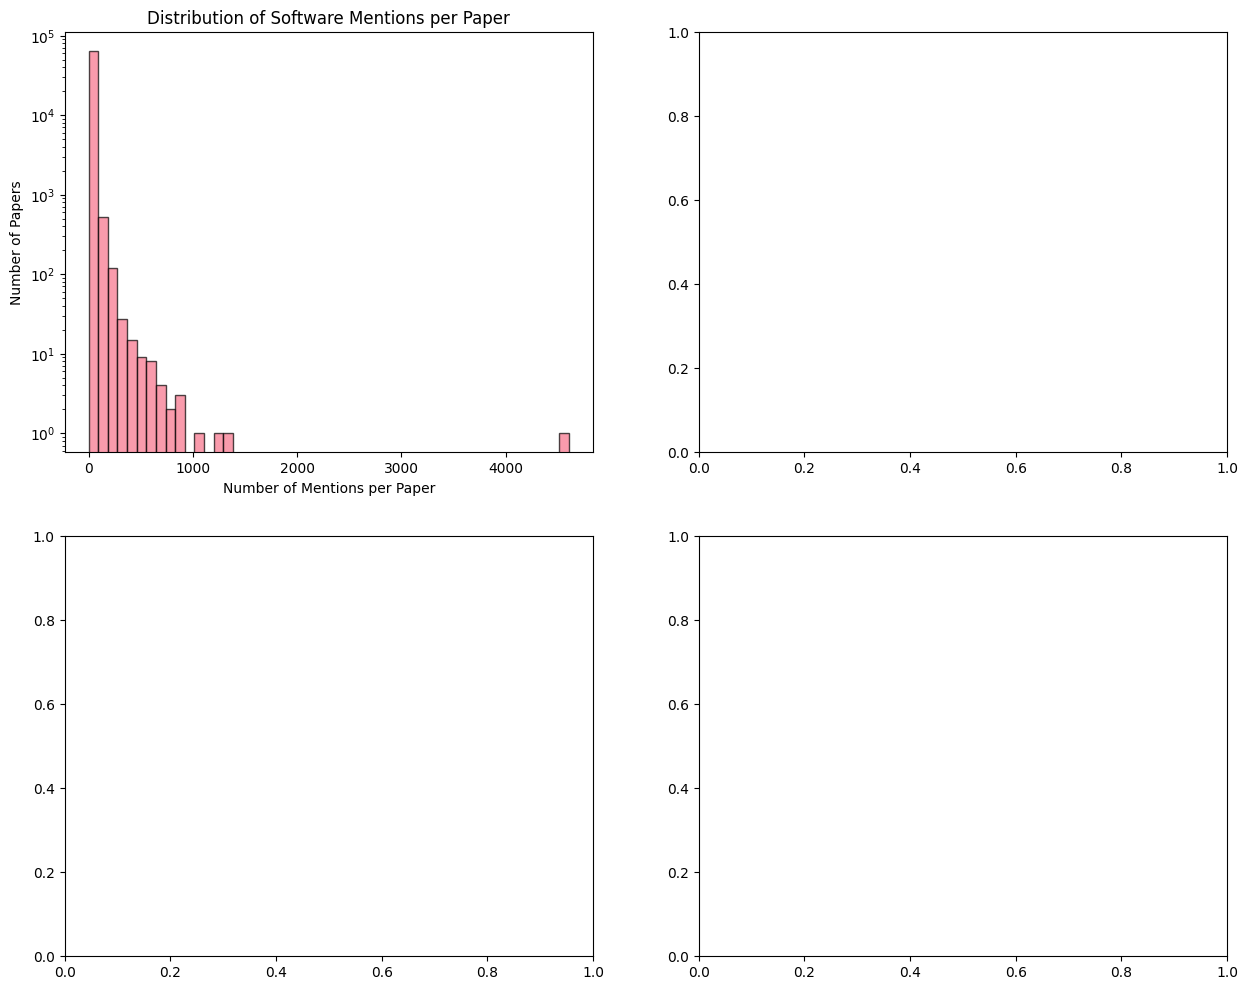

In [52]:
# Visualizations for software mention patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of mentions per paper
axes[0, 0].hist(mentions_per_paper['mention_count'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Number of Mentions per Paper')
axes[0, 0].set_ylabel('Number of Papers')
axes[0, 0].set_title('Distribution of Software Mentions per Paper')
axes[0, 0].set_yscale('log')

# 2. Top 15 most mentioned software
top_15_software = software_counts.head(15)
axes[0, 1].barh(range(len(top_15_software)), top_15_software.values)
axes[0, 1].set_yticks(range(len(top_15_software)))
axes[0, 1].set_yticklabels(top_15_software.index)
axes[0, 1].set_xlabel('Number of Mentions')
axes[0, 1].set_title('Top 15 Most Mentioned Software')

# 3. Papers with most mentions (top 20)
top_20_papers = mentions_per_paper.nlargest(20, 'mention_count')
axes[1, 0].bar(range(len(top_20_papers)), top_20_papers['mention_count'])
axes[1, 0].set_xlabel('Paper Rank')
axes[1, 0].set_ylabel('Number of Mentions')
axes[1, 0].set_title('Top 20 Papers by Mention Count')

# 4. Software diversity per paper (if we have enough data)
if len(mentions_per_paper) > 0:
    # Calculate unique software per paper
    unique_software_per_paper = mentions_df.groupby('paper_id')['software_normalized'].nunique().reset_index(name='unique_software_count')
    axes[1, 1].hist(unique_software_per_paper['unique_software_count'], bins=30, alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Number of Unique Software per Paper')
    axes[1, 1].set_ylabel('Number of Papers')
    axes[1, 1].set_title('Distribution of Software Diversity per Paper')

plt.tight_layout()
plt.show()


## Section 5: Purpose Assessments Analysis

Each mention has six purpose assessments (3 purposes x 2 scopes). We examine the distribution of scopes, purposes, certainty scores, and co-occurrence patterns.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scope_counts = purpose_df['scope'].value_counts()
scope_counts.plot(kind='bar', ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title("Assessments by Scope")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(scope_counts.values):
    axes[0].text(i, v + v * 0.01, f"{v:,}", ha='center', fontsize=9)

purpose_counts = purpose_df['purpose'].value_counts()
purpose_counts.plot(kind='bar', ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title("Assessments by Purpose")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(purpose_counts.values):
    axes[1].text(i, v + v * 0.01, f"{v:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Scope x Purpose cross-tabulation:")
display(pd.crosstab(purpose_df['scope'], purpose_df['purpose'], margins=True))

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, scope in enumerate(['document', 'local']):
    for j, purpose in enumerate(['used', 'created', 'shared']):
        ax = axes[i][j]
        subset = purpose_df[(purpose_df['scope'] == scope) & (purpose_df['purpose'] == purpose)]
        ax.hist(subset['certainty_score'], bins=50, edgecolor='black', linewidth=0.2, alpha=0.8)
        ax.set_title(f"{scope} / {purpose}")
        ax.set_xlabel("Certainty Score")
        ax.set_ylabel("Count")
        ax.set_yscale('log')

plt.suptitle("Certainty Score Distributions by Scope and Purpose (log scale)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Certainty score statistics by scope + purpose:")
display(purpose_df.groupby(['scope', 'purpose'])['certainty_score'].describe())

In [ ]:
high_conf = purpose_df[
    (purpose_df['certainty_score'] > 0.5) &
    (purpose_df['scope'] == 'document') &
    (purpose_df['purpose'] == 'used')
]

total_mentions = purpose_df['software_mention_id'].nunique()
hc_mentions = high_conf['software_mention_id'].nunique()
hc_papers = high_conf['paper_id'].nunique()
total_papers = papers_df.shape[0]

print("High-Confidence 'Used' Classification (document scope, certainty > 0.5)")
print(f"  Mentions with confident 'used': {hc_mentions:,} / {total_mentions:,} ({hc_mentions/total_mentions*100:.1f}%)")
print(f"  Papers with at least one: {hc_papers:,} / {total_papers:,} ({hc_papers/total_papers*100:.1f}%)")
print(f"  Mean certainty in this group: {high_conf['certainty_score'].mean():.3f}")
print(f"  Median certainty in this group: {high_conf['certainty_score'].median():.3f}")

In [ ]:
doc_purposes = purpose_df[purpose_df['scope'] == 'document'].copy()

pivot = doc_purposes.pivot_table(
    index='software_mention_id',
    columns='purpose',
    values='certainty_score',
    aggfunc='first'
)

high_threshold = 0.5
multi_purpose = pivot[(pivot > high_threshold).sum(axis=1) >= 2]

print(f"Mentions with high certainty (>{high_threshold}) in 2+ purposes (document scope):")
print(f"  {len(multi_purpose):,} / {len(pivot):,} ({len(multi_purpose)/len(pivot)*100:.1f}%)")

combos = (pivot > high_threshold).groupby(
    [(pivot > high_threshold)['used'], (pivot > high_threshold)['created'], (pivot > high_threshold)['shared']]
).size().reset_index(name='count')
combos.columns = ['used_high', 'created_high', 'shared_high', 'count']
combos['pct'] = (combos['count'] / combos['count'].sum() * 100).round(2)
combos = combos.sort_values('count', ascending=False)
print("\nPurpose co-occurrence patterns (document scope, certainty > 0.5):")
display(combos)

## Section 6: Cross-Table Analysis

Joining papers, mentions, and purpose assessments to explore temporal trends, genre effects, and purpose-specific software rankings.

In [ ]:
top10_sw = mentions_df['software_normalized'].value_counts().head(10).index.tolist()
mentions_top10 = mentions_df[mentions_df['software_normalized'].isin(top10_sw)][['paper_id', 'software_normalized']]
merged = mentions_top10.merge(papers_df[['paper_id', 'published_year']], on='paper_id', how='inner')
merged = merged[(merged['published_year'] >= 2000) & (merged['published_year'] <= 2024)]

yearly = (
    merged.drop_duplicates(subset=['paper_id', 'software_normalized'])
    .groupby(['published_year', 'software_normalized'])
    .size()
    .reset_index(name='paper_count')
)

fig, ax = plt.subplots(figsize=(14, 7))
for sw in top10_sw:
    sw_data = yearly[yearly['software_normalized'] == sw]
    ax.plot(sw_data['published_year'], sw_data['paper_count'], marker='.', label=sw, linewidth=1.5)

ax.set_title("Top 10 Software: Distinct Papers per Year (2000–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Distinct Papers")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
papers_with_year = papers_df[papers_df['published_year'].between(1990, 2024)].copy()
mention_counts_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='n_mentions')

merged_mc = papers_with_year[['paper_id', 'published_year']].merge(
    mention_counts_per_paper, on='paper_id', how='left'
)
merged_mc['n_mentions'] = merged_mc['n_mentions'].fillna(0)

yearly_stats = merged_mc.groupby('published_year').agg(
    total_papers=('paper_id', 'count'),
    papers_with_mentions=('n_mentions', lambda x: (x > 0).sum()),
    mean_mentions=('n_mentions', 'mean'),
    median_mentions=('n_mentions', 'median')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(yearly_stats['published_year'], yearly_stats['mean_mentions'], marker='.', label='Mean')
axes[0].plot(yearly_stats['published_year'], yearly_stats['median_mentions'], marker='.', label='Median')
axes[0].set_title("Average Software Mentions per Paper by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mentions per Paper")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

pct = yearly_stats['papers_with_mentions'] / yearly_stats['total_papers'] * 100
axes[1].plot(yearly_stats['published_year'], pct, marker='.', color='green')
axes[1].set_title("% of Papers with At Least One Software Mention by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of Papers")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
mention_counts_by_paper = mentions_df.groupby('paper_id').size().reset_index(name='n_mentions')
genre_mentions = papers_df[['paper_id', 'genre']].merge(mention_counts_by_paper, on='paper_id', how='left')
genre_mentions['n_mentions'] = genre_mentions['n_mentions'].fillna(0)

genre_stats = genre_mentions.groupby('genre').agg(
    total_papers=('paper_id', 'count'),
    papers_with_mentions=('n_mentions', lambda x: (x > 0).sum()),
    mean_mentions=('n_mentions', 'mean'),
    median_mentions=('n_mentions', 'median')
).reset_index()
genre_stats['pct_with_mentions'] = (genre_stats['papers_with_mentions'] / genre_stats['total_papers'] * 100).round(1)
genre_stats = genre_stats.sort_values('mean_mentions', ascending=False)

display(genre_stats.head(15))

fig, ax = plt.subplots(figsize=(12, 6))
top_genres = genre_stats[genre_stats['total_papers'] >= 100].head(12)
ax.barh(top_genres['genre'], top_genres['mean_mentions'], edgecolor='black', linewidth=0.3)
ax.set_xlabel("Mean Software Mentions per Paper")
ax.set_title("Average Software Mentions by Genre (genres with 100+ papers)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
doc_purposes = purpose_df[
    (purpose_df['scope'] == 'document') &
    (purpose_df['certainty_score'] > 0.5)
]

mentions_slim = mentions_df[['software_mention_id', 'software_normalized', 'paper_id']]
merged_purpose = doc_purposes[['software_mention_id', 'purpose']].merge(
    mentions_slim, on='software_mention_id', how='inner'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, purpose_name in enumerate(['used', 'created', 'shared']):
    subset = merged_purpose[merged_purpose['purpose'] == purpose_name]
    top_sw = (
        subset.drop_duplicates(subset=['paper_id', 'software_normalized'])
        .groupby('software_normalized').size()
        .nlargest(10)
    )
    top_sw.plot(kind='barh', ax=axes[i], edgecolor='black', linewidth=0.3)
    axes[i].set_title(f"Top 10 '{purpose_name}' Software\n(document scope, certainty > 0.5)")
    axes[i].set_xlabel("Distinct Papers")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
mc_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='n_mentions')
license_data = papers_df[['paper_id', 'license_type', 'has_mentions']].merge(
    mc_per_paper, on='paper_id', how='left'
)
license_data['n_mentions'] = license_data['n_mentions'].fillna(0)

license_stats = license_data.groupby('license_type').agg(
    total_papers=('paper_id', 'count'),
    pct_with_mentions=('has_mentions', lambda x: x.mean() * 100),
    mean_mentions=('n_mentions', 'mean')
).reset_index()
license_stats = license_stats.sort_values('mean_mentions', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(license_stats['license_type'], license_stats['pct_with_mentions'], edgecolor='black', linewidth=0.3)
axes[0].set_xlabel("% of Papers with Software Mentions")
axes[0].set_title("Mention Rate by License Type")
axes[0].invert_yaxis()

axes[1].barh(license_stats['license_type'], license_stats['mean_mentions'], edgecolor='black', linewidth=0.3)
axes[1].set_xlabel("Mean Mentions per Paper")
axes[1].set_title("Average Mentions by License Type")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

display(license_stats)

## Custom Analysis

You can now easily analyze any specific software by modifying the code below:


In [ ]:
# CUSTOM ANALYSIS - Change the software name here to analyze any software
# You can use either normalized names (recommended) or raw names

# Example: Analyze a specific software
software_name = "R"  # Change this to any software you want to analyze
use_normalized = True  # Set to False to use raw software names

# Run the analysis
result = analyze_software_mentions(software_name, use_normalized)

# If you want to see the actual papers that mention this software most:
if result is not None:
    print(f"\nDetailed breakdown for '{software_name}':")
    print("Papers with most mentions:")
    print(result.nlargest(10, 'mention_count'))
